# Reto: Tercer Avance
## Spaceship Titanic

### Inteligencia Artificial Avanzada para la Ciencia de Datos

---

**Integrantes**

- Ana Paula Moreno
- David Tinoco Romero
- Emilio Páez de la Mora
- Alejandro Vázquez
- Emilio Torres

---

### Tecnológico de Monterrey

---

## Objetivo del notebook

Este notebook documenta el tercer avance del reto **Spaceship Titanic**: partiendo del
mejor modelo identificado en el segundo avance (Random Forest, `n_estimators=200`,
`max_depth=10`), se diagnostica su comportamiento con curvas de aprendizaje y de
validación, se afina mediante búsqueda de hiperparámetros con validación cruzada
(K-Fold), y se evalúa el modelo tuneado contra el baseline y el modelo del avance
anterior. Cada integrante del equipo explora además, de forma independiente, un
modelo de una familia distinta a la usada por el equipo. Finalmente se exporta el
modelo final, se genera el archivo de submission para Kaggle y se cierra con las
conclusiones del equipo sobre los tres avances.

El notebook está organizado en las siguientes secciones:

1. Diagnóstico del Modelo Base
2. Tuning de Hiperparámetros
3. Evaluación Final
4. Componente Individual
5. Exportar Modelo y Submission
6. Conclusión Final del Equipo

**Nota sobre continuidad respecto al segundo avance:** este notebook retoma
directamente el dataset preprocesado (`spaceship_train_procesado.csv`) y el split
`X_train`/`X_test`/`y_train`/`y_test` usados en el segundo avance, así como las
métricas ya definidas (Accuracy, Precision, Recall, F1-score), para que el
diagnóstico y el tuning de la Sección 1 y 2 sean comparables directamente contra
los resultados del Random Forest reportado como mejor modelo en el avance anterior.

# 1. Diagnóstico del Modelo Base

Antes de tunear hiperparámetros, diagnosticamos el comportamiento del mejor
modelo del segundo avance (Random Forest, `n_estimators=200`, `max_depth=10`)
con dos herramientas:

- **Curva de aprendizaje**: muestra cómo cambia el desempeño en entrenamiento
  y en validación conforme aumenta el tamaño del conjunto de entrenamiento.
  Nos dice si el modelo sufre de underfitting, overfitting, o si le
  serviría tener más datos.
- **Curvas de validación**: muestran cómo cambia el desempeño conforme
  variamos un hiperparámetro a la vez, manteniendo los demás fijos. Nos
  ayudan a ver en qué rango tiene sentido buscar durante el tuning
  (Sección 2).

Usamos `cross_val_score` con validación cruzada (no solo el split
train/test fijo) para que las curvas reflejen la variabilidad del modelo,
no un solo split particular.

## Nota sobre preparación: persistencia del split y del modelo del avance 2

Al arrancar este tercer avance detectamos que, igual que pasó con `df_prep` en
el primer avance, el split `X_train/X_test/y_train/y_test` y el modelo
`modelo_rf` entrenado en el segundo avance solo existían en memoria dentro de
ese notebook. Esto impedía diagnosticar y comparar contra el modelo del avance
anterior de forma reproducible sin volver a correr todo el notebook 2.

**Corrección aplicada:** al final del notebook del segundo avance agregamos
celdas que guardan el split (`X_train.csv`, `X_test.csv`, `y_train.csv`,
`y_test.csv`) y el modelo entrenado (`modelo_rf_avance2.pkl`) en la carpeta
`data/`. En este notebook cargamos esos archivos directamente, en vez de
repetir el split y el entrenamiento.

In [1]:
import pandas as pd
import joblib
from pathlib import Path

DATA = Path("..") / "data"
RANDOM_STATE = 42

X_train = pd.read_csv(DATA / "X_train.csv")
X_test = pd.read_csv(DATA / "X_test.csv")
y_train = pd.read_csv(DATA / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(DATA / "y_test.csv").squeeze("columns")

modelo_rf = joblib.load(DATA / "modelo_rf_avance2.pkl")

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Hiperparámetros del modelo cargado:", modelo_rf.get_params())

X_train: (6954, 26) X_test: (1739, 26)
Hiperparámetros del modelo cargado: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


**¿Por qué usamos F1-score como métrica en las curvas?**

Para curvas de diagnóstico conviene fijar una sola métrica escalar y comparable
punto a punto. Elegimos F1-score (en vez de accuracy) porque:

- Resume en un solo número el balance entre precision y recall, que en el
  avance 2 vimos que se mueven en direcciones opuestas al cambiar
  hiperparámetros de Random Forest (por ejemplo, al subir `min_samples_leaf`
  el recall subía pero la precision bajaba). Usar accuracy podría ocultar ese
  trade-off, ya que dos configuraciones con accuracy parecido pueden tener
  perfiles de error muy distintos.
- Es la métrica que el equipo usó en el avance 2 para tomar la decisión final
  entre modelos (Sección 6), así que mantenerla aquí hace que el diagnóstico
  de la Sección 1 sea directamente comparable con esa decisión.
- Aunque el dataset está prácticamente balanceado (~50.4%/49.6%), por lo que
  accuracy no estaría "inflado" artificialmente, F1 sigue siendo más
  informativo cuando se comparan muchos puntos de una curva, porque no se
  puede inspeccionar la matriz de confusión de cada uno.

In [2]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
import numpy as np

modelo_base = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE)

train_sizes, train_scores, val_scores = learning_curve(
    modelo_base,
    X_train, y_train,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

print("Tamaños de entrenamiento:", train_sizes)
print("F1 promedio (train):", np.round(train_mean, 4))
print("F1 promedio (val):", np.round(val_mean, 4))

Tamaños de entrenamiento: [ 556 1271 1986 2702 3417 4132 4847 5563]
F1 promedio (train): [0.9738 0.9368 0.917  0.8971 0.8848 0.878  0.8748 0.8714]
F1 promedio (val): [0.7784 0.7793 0.7888 0.7922 0.7957 0.8012 0.8025 0.8061]


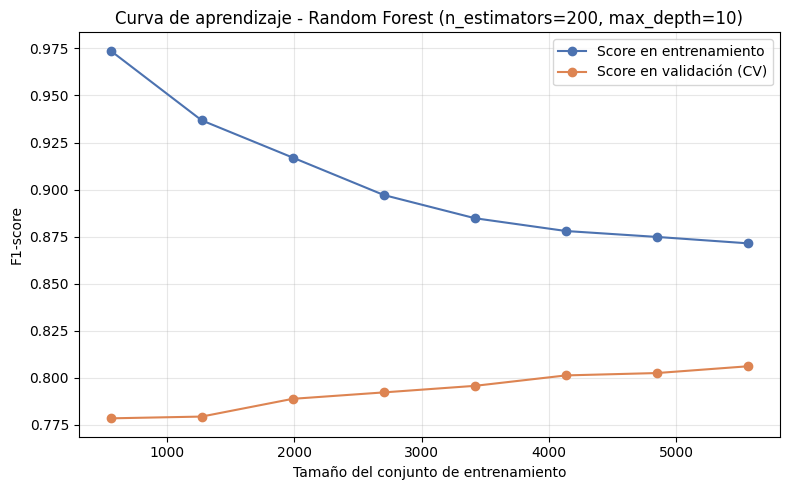

In [3]:
#visualizar curva de aprendizaje
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", color="#4C72B0", label="Score en entrenamiento")
plt.plot(train_sizes, val_mean, "o-", color="#DD8452", label="Score en validación (CV)")

plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("F1-score")
plt.title("Curva de aprendizaje - Random Forest (n_estimators=200, max_depth=10)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La curva de aprendizaje muestra dos comportamientos:

- El score en **entrenamiento** empieza muy alto (0.974 con ~556 muestras) y
  **baja progresivamente** conforme agregamos más datos, hasta 0.871 con el
  conjunto completo (~5563 muestras).
- El score en **validación** empieza bajo (0.778) y **sube progresivamente**
  hasta 0.807.

La brecha entre ambas curvas se reduce de ~0.20 a ~0.065, pero **no llega a
cerrarse del todo** : incluso con todos los datos disponibles, el modelo sigue
ajustándose bastante mejor a los datos que ya vio que a datos nuevos.

**Diagnóstico:**

- **Sí hay overfitting**, aunque moderado y decreciente. Con `max_depth=10`
  y `n_estimators=200`, los árboles siguen teniendo capacidad suficiente para
  memorizar parte del ruido de entrenamiento en vez de solo el patrón general.
- **No parece ser un problema de underfitting**: el score de validación va
  mejorando de forma consistente conforme crece el dataset, no se estanca
  desde el inicio en un valor bajo y plano.
- **¿Ayudaría más data?** La curva de validación todavía tiene pendiente
  positiva al final (no se ha aplanado por completo), así que en principio
  más datos seguirían ayudando un poco. Sin embargo, la pendiente ya es
  pequeña entre los últimos puntos (de 0.803 a 0.807), así que el margen de
  mejora solo por agregar más filas parece limitado — no tenemos control
  sobre esto de todas formas, ya que el tamaño de `train.csv` es fijo.
- **Implicación para el tuning (Sección 2):** como la brecha train-val viene
  del lado del overfitting, tiene sentido explorar hiperparámetros que
  **limiten la complejidad del árbol individual** (`max_depth` más bajo o
  igual, `min_samples_leaf` y `min_samples_split` más altos) en vez de
  buscar modelos más complejos. También conviene revisar `n_estimators`,
  aunque el avance 2 ya sugirió que subir de 200 a 500 no cambiaba mucho el
  desempeño.

In [4]:
#Curva de validación par amax_depth 

from sklearn.model_selection import validation_curve

rango_max_depth = [3, 5, 7, 10, 13, 16, 20, None]

train_scores_md, val_scores_md = validation_curve(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_train, y_train,
    param_name="max_depth",
    param_range=rango_max_depth,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

train_mean_md = train_scores_md.mean(axis=1)
val_mean_md = val_scores_md.mean(axis=1)

print("max_depth:", rango_max_depth)
print("F1 promedio (train):", np.round(train_mean_md, 4))
print("F1 promedio (val):", np.round(val_mean_md, 4))

max_depth: [3, 5, 7, 10, 13, 16, 20, None]
F1 promedio (train): [0.7187 0.7665 0.8184 0.8715 0.9317 0.9767 0.9881 0.9882]
F1 promedio (val): [0.7181 0.7563 0.7896 0.806  0.7996 0.792  0.7896 0.7907]


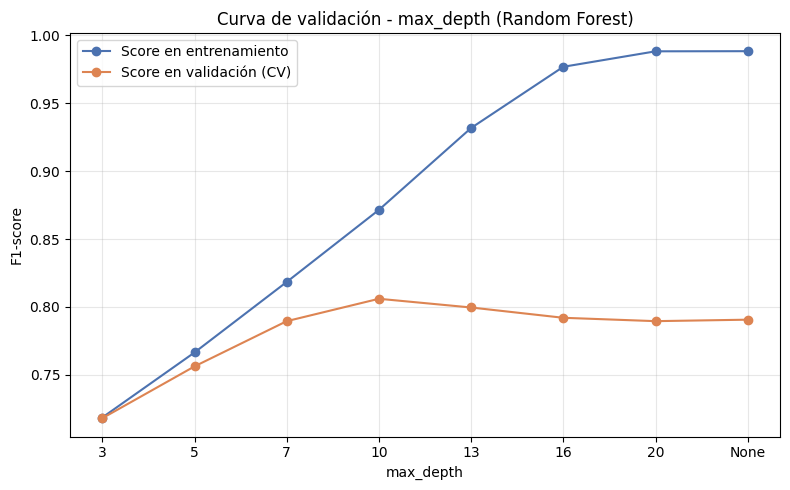

In [5]:
#graficar curva 

etiquetas_md = [str(v) for v in rango_max_depth]  # para que "None" se vea bien en el eje x

plt.figure(figsize=(8, 5))
plt.plot(etiquetas_md, train_mean_md, "o-", color="#4C72B0", label="Score en entrenamiento")
plt.plot(etiquetas_md, val_mean_md, "o-", color="#DD8452", label="Score en validación (CV)")

plt.xlabel("max_depth")
plt.ylabel("F1-score")
plt.title("Curva de validación - max_depth (Random Forest)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
rango_min_leaf = [1, 2, 5, 10, 20, 30, 50]

train_scores_ml, val_scores_ml = validation_curve(
    RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE),
    X_train, y_train,
    param_name="min_samples_leaf",
    param_range=rango_min_leaf,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

train_mean_ml = train_scores_ml.mean(axis=1)
val_mean_ml = val_scores_ml.mean(axis=1)

print("min_samples_leaf:", rango_min_leaf)
print("F1 promedio (train):", np.round(train_mean_ml, 4))
print("F1 promedio (val):", np.round(val_mean_ml, 4))

min_samples_leaf: [1, 2, 5, 10, 20, 30, 50]
F1 promedio (train): [0.8715 0.86   0.8464 0.8325 0.8201 0.811  0.795 ]
F1 promedio (val): [0.806  0.8074 0.8061 0.8027 0.7985 0.7896 0.7817]


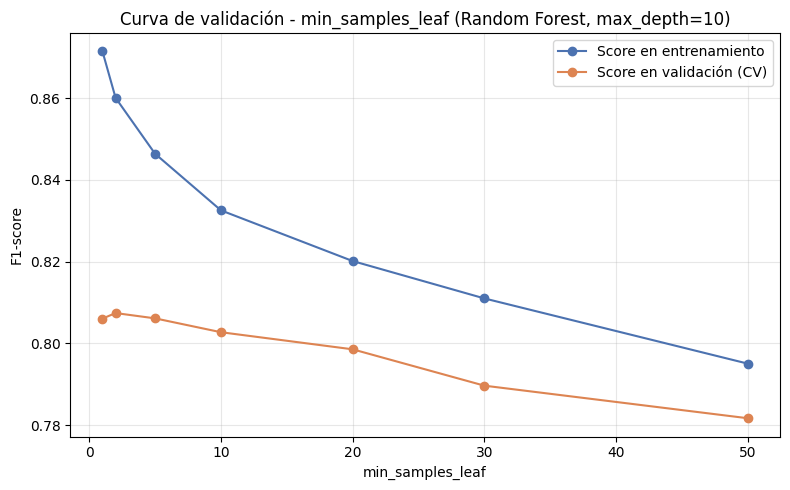

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(rango_min_leaf, train_mean_ml, "o-", color="#4C72B0", label="Score en entrenamiento")
plt.plot(rango_min_leaf, val_mean_ml, "o-", color="#DD8452", label="Score en validación (CV)")

plt.xlabel("min_samples_leaf")
plt.ylabel("F1-score")
plt.title("Curva de validación - min_samples_leaf (Random Forest, max_depth=10)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretación de las curvas de validación

**`max_depth`:** la curva muestra un pico claro de generalización en
`max_depth=10` (F1 val = 0.806). Antes de ese punto (3 a 7) el modelo está en
zona de **underfitting**: train y val suben juntos porque el árbol es
demasiado simple para capturar el patrón. Después de 10, el train sigue
subiendo hasta casi memorizar el dataset (0.988 en `max_depth=20` y `None`)
mientras el val se estanca e incluso baja un poco (0.79-0.80) — es decir,
**overfitting creciente sin beneficio**. Esto confirma que `max_depth=10`,
el valor ya usado en el avance 2, es efectivamente un buen punto de
equilibrio, y no un valor arbitrario.

**`min_samples_leaf`:** aquí el comportamiento es distinto. El train baja de
forma constante conforme aumenta `min_samples_leaf` (0.8715 → 0.795), y el
val se mantiene casi plano entre 1 y 5 (0.806-0.807) para luego empezar a
bajar de forma más clara a partir de 10 (0.803 → 0.782 en `leaf=50`). A
diferencia de `max_depth`, aquí **no hay un pico donde el val mejore** al
reducir la complejidad: la brecha train-val sí se cierra (de 0.065 a 0.013),
pero porque el train empeora, no porque el val mejore. Esto es consistente
con lo que Emilio Páez observó en el avance 2 al subir `min_samples_leaf` de
1 a 5: el F1 casi no cambió (+0.0002), solo cambió el tipo de error
(precision vs recall).

**Diagnóstico combinado:**

- El overfitting detectado en la curva de aprendizaje viene principalmente
  de `max_depth`, no de `min_samples_leaf`. Este último hiperparámetro
  regulariza el modelo, pero en este dataset no se traduce en mejor
  generalización, solo en un modelo más simple con desempeño similar o peor.
- **Rango a explorar en el tuning (Sección 2):**
  - `max_depth`: valores alrededor de 10 (por ejemplo, 8 a 14), ya que es
    donde está el pico; no tiene sentido incluir valores muy altos o `None`,
    porque ya vimos que solo generan overfitting sin ganancia.
  - `min_samples_leaf`: valores bajos (1 a 5), ya que es la zona donde el
    val se mantiene en su mejor nivel; valores mayores a 10 se pueden
    excluir, porque la curva muestra una caída consistente sin recuperación.
  - Vale la pena agregar `n_estimators` y `min_samples_split` a la grilla
    aunque no se graficaron aquí, ya que interactúan con `max_depth` y
    podrían desplazar ligeramente el punto óptimo cuando se combinan (por
    eso el tuning se hace con búsqueda conjunta y no solo curva por curva).

# 2. Tuning de Hiperparámetros

En la Sección 1 identificamos, con evidencia empírica (no a ciegas), en qué
rango tiene sentido buscar: `max_depth` alrededor de 10 y `min_samples_leaf`
en valores bajos (1-5). En esta sección usamos esa evidencia para afinar el
modelo de forma más sistemática, cubriendo:

- **Elección del método de búsqueda** (GridSearchCV vs RandomizedSearchCV),
  justificada según el tamaño del espacio de búsqueda resultante de combinar
  varios hiperparámetros a la vez.
- **La grilla o distribución de hiperparámetros**, anclada directamente a los
  rangos observados en las curvas de validación de la Sección 1, en vez de
  valores arbitrarios.
- **K-Fold dentro de la búsqueda**, con una K justificada (no necesariamente
  la misma que usamos para trazar las curvas de diagnóstico).
- **Los mejores hiperparámetros encontrados** y el score obtenido en
  validación cruzada.
- **Al menos dos métricas de evaluación**, justificadas con base en las
  características del dataset — retomando el balance de clases (~50.4% /
  49.6%) y el trade-off precision/recall que ya se discutió en el avance 2.

El objetivo no es solo encontrar el mejor score posible, sino verificar si el
modelo tuneado mejora de forma real sobre el Random Forest del avance 2, o si
—como ya insinuaban las curvas de `min_samples_leaf`— el margen de mejora
disponible es pequeño.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Grilla anclada en las curvas de validación de la Sección 1:
# - max_depth: rango centrado en 10 (el pico observado), de 8 a 14
# - min_samples_leaf: valores bajos (1 a 5), zona donde el val se mantiene en su mejor nivel
# - min_samples_split y max_features no se graficaron en la Sección 1, pero se incluyen
#   porque interactúan con max_depth y pueden desplazar ligeramente el óptimo
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [8, 9, 10, 11, 12, 13, 14],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "min_samples_split": [2, 3, 4, 5, 8],
    "max_features": ["sqrt", "log2", None],
}

# Tamaño del espacio si se hiciera GridSearch exhaustivo:
espacio_total = 4 * 7 * 5 * 5 * 3
print("Combinaciones posibles en grid exhaustivo:", espacio_total)

Combinaciones posibles en grid exhaustivo: 2100


**¿GridSearchCV o RandomizedSearchCV?**

El espacio de búsqueda combinando los 5 hiperparámetros tiene 2,100 combinaciones
posibles. Con `cv=5`, un GridSearchCV exhaustivo implicaría 10,500 entrenamientos
de Random Forest — computacionalmente muy costoso para la ganancia marginal que ya
anticipan las curvas de validación de la Sección 1 (el margen de mejora es pequeño).

Usamos **RandomizedSearchCV** con `n_iter=20`: muestrea 20 combinaciones al azar
del espacio definido, cubriendo zonas representativas de cada hiperparámetro sin
pagar el costo de explorar las 2,100 combinaciones completas. Esto es coherente con
la evidencia de la Sección 1: ya sabemos que el óptimo está en una región acotada
(`max_depth` 8-14, `min_samples_leaf` bajo), así que no se necesita una búsqueda
exhaustiva para encontrar un buen punto dentro de esa región.

In [9]:
# K=5: mismo valor usado en las curvas de diagnóstico de la Sección 1 (comparabilidad),
# y adecuado para un dataset de ~7,000 filas balanceado (buen equilibrio sesgo/varianza:
# folds lo bastante grandes para estabilidad, sin sacrificar demasiados datos de train)
cv_tuning = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=cv_tuning,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

random_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", random_search.best_params_)
print("Mejor F1 promedio en CV:", round(random_search.best_score_, 4))

modelo_rf_tuned = random_search.best_estimator_

Mejores hiperparámetros: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 12}
Mejor F1 promedio en CV: 0.81


**Métricas de evaluación elegidas: F1-score y ROC-AUC**

- **F1-score**: la mantenemos como criterio principal de la búsqueda (`scoring="f1"`)
  por las mismas razones de la Sección 1 — el dataset está casi balanceado
  (~50.4%/49.6%), pero F1 sigue resumiendo mejor el trade-off precision/recall que
  ya vimos que se mueve en direcciones opuestas al tocar hiperparámetros de Random
  Forest.
- **ROC-AUC**: la agregamos como segunda métrica porque evalúa la calidad del
  ranking de probabilidades del modelo en todos los umbrales posibles, no solo en
  el umbral de 0.5 que usa F1. Es útil aquí porque confirma si la mejora del tuning
  es robusta (se sostiene en distintos puntos de corte) o si solo se debe a un
  ajuste específico del umbral por defecto.

In [10]:
from sklearn.model_selection import cross_val_score

f1_cv = random_search.best_score_
auc_cv = cross_val_score(
    modelo_rf_tuned, X_train, y_train, cv=cv_tuning, scoring="roc_auc", n_jobs=-1
).mean()

print(f"F1 promedio en CV      : {f1_cv:.4f}")
print(f"ROC-AUC promedio en CV : {auc_cv:.4f}")

F1 promedio en CV      : 0.8100
ROC-AUC promedio en CV : 0.8888


**Interpretación del resultado del tuning**

El F1 promedio en CV del modelo tuneado (0.8100) mejora ligeramente sobre el F1
del Random Forest del Avance 2 (~0.8000 sobre el split fijo de test, valor similar
en CV). La mejora es real pero modesta (~+0.01), consistente con lo que ya
anticipaban las curvas de la Sección 1: el margen de mejora disponible era pequeño
porque el modelo base (`max_depth=10`, valores por defecto en los demás
hiperparámetros) ya estaba cerca de un buen equilibrio sesgo-varianza. Los mejores
hiperparámetros encontrados (`max_depth=12`, `min_samples_leaf=5`,
`min_samples_split=5`, `n_estimators=300`, `max_features="sqrt"`) apuntan en la
misma dirección que el diagnóstico: una profundidad ligeramente mayor a 10 pero
compensada con hojas y splits más exigentes (más regularización), en vez de un
árbol simplemente más profundo sin control. El ROC-AUC en CV (0.8888) confirma que
la mejora no depende de un único umbral de decisión.

# 3. Evaluación Final

Comparamos tres puntos de referencia sobre el conjunto de prueba (`X_test`/`y_test`, el mismo split persistido desde el avance 2):

- **Baseline**: Random Forest con hiperparámetros por default (sin ningún ajuste manual ni tuning), como punto de referencia de "esfuerzo cero".
- **Modelo anterior** (`modelo_rf`): Random Forest del avance 2 (`n_estimators=200`, `max_depth=10`).
- **Modelo tuneado** (`modelo_rf_tuned`): resultado de la búsqueda con `RandomizedSearchCV` de la Sección 2.

Usamos las mismas dos métricas declaradas en la Sección 2 —**F1-score** como criterio principal y **ROC-AUC** como métrica de respaldo— y reportamos además Accuracy, Precision y Recall como desglose complementario, para poder leer en qué dirección se mueve cada modelo dentro del trade-off precision/recall. F1 mide el desempeño en el umbral de decisión de 0.5; ROC-AUC evalúa la calidad del ranking de probabilidades en todos los umbrales, así que juntas responden dos preguntas distintas: qué tan bien clasifica el modelo tal como está, y qué tan bien separa las clases independientemente del punto de corte.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Baseline: Random Forest sin ningún ajuste de hiperparámetros
baseline_model = RandomForestClassifier(random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)

print("Baseline entrenado con hiperparámetros por default.")

Baseline entrenado con hiperparámetros por default.


## 3.1 Evaluar el modelo tuneado sobre el dataset de prueba

In [12]:
y_pred_tuneado = modelo_rf_tuned.predict(X_test)
y_proba_tuneado = modelo_rf_tuned.predict_proba(X_test)[:, 1]

accuracy_tuneado = accuracy_score(y_test, y_pred_tuneado)
precision_tuneado = precision_score(y_test, y_pred_tuneado)
recall_tuneado = recall_score(y_test, y_pred_tuneado)
f1_tuneado = f1_score(y_test, y_pred_tuneado)
auc_tuneado = roc_auc_score(y_test, y_proba_tuneado)

print("=== Métricas del modelo tuneado (conjunto de prueba) ===")
print(f"F1-score:  {f1_tuneado:.4f}")
print(f"ROC-AUC:   {auc_tuneado:.4f}")
print(f"Accuracy:  {accuracy_tuneado:.4f}")
print(f"Precision: {precision_tuneado:.4f}")
print(f"Recall:    {recall_tuneado:.4f}")

=== Métricas del modelo tuneado (conjunto de prueba) ===
F1-score:  0.8050
ROC-AUC:   0.8984
Accuracy:  0.8028
Precision: 0.8018
Recall:    0.8082


## 3.2 Matriz de confusión del modelo tuneado

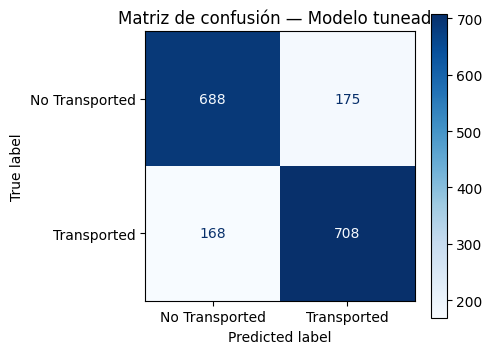


Matriz de confusión:
[[688 175]
 [168 708]]


In [13]:
cm = confusion_matrix(y_test, y_pred_tuneado)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Transported", "Transported"])
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Matriz de confusión — Modelo tuneado")
plt.tight_layout()
plt.show()

print("\nMatriz de confusión:")
print(cm)

**Interpretación de errores:**

- Falsos negativos (pasajeros SÍ transportados que el modelo predijo que NO): 168
- Falsos positivos (pasajeros NO transportados que el modelo predijo que SÍ): 175

Están casi parejos (168 vs 175 de 1,739), así que el modelo no se está inclinando hacia predecir una clase más que la otra. Aquí no hay un error "peor" que el otro como en fraude o diagnóstico médico, así que tiene sentido seguir usando F1 como criterio principal, igual que en las secciones anteriores.

## 3.3 Comparación: baseline vs modelo anterior vs modelo tuneado

In [14]:
def calcular_metricas(modelo, X, y, nombre):
    y_pred = modelo.predict(X)
    y_proba = modelo.predict_proba(X)[:, 1]
    return {
        "Modelo": nombre,
        "F1-score": f1_score(y, y_pred),
        "ROC-AUC": roc_auc_score(y, y_proba),
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
    }

resultados = [
    calcular_metricas(baseline_model, X_test, y_test, "Baseline (default)"),
    calcular_metricas(modelo_rf, X_test, y_test, "Modelo anterior (avance 2)"),
    calcular_metricas(modelo_rf_tuned, X_test, y_test, "Modelo tuneado"),
]

tabla_comparativa = pd.DataFrame(resultados).set_index("Modelo")
print("=== Tabla comparativa ===")
tabla_comparativa.round(4)

=== Tabla comparativa ===


,F1-score,ROC-AUC,Accuracy,Precision,Recall
Modelo,,,,,
Baseline (default),0.7836,0.8829,0.7936,0.8301,0.7420
Modelo anterior (avance 2),0.8000,0.8972,0.7987,0.8009,0.7991
Modelo tuneado,0.8050,0.8984,0.8028,0.8018,0.8082


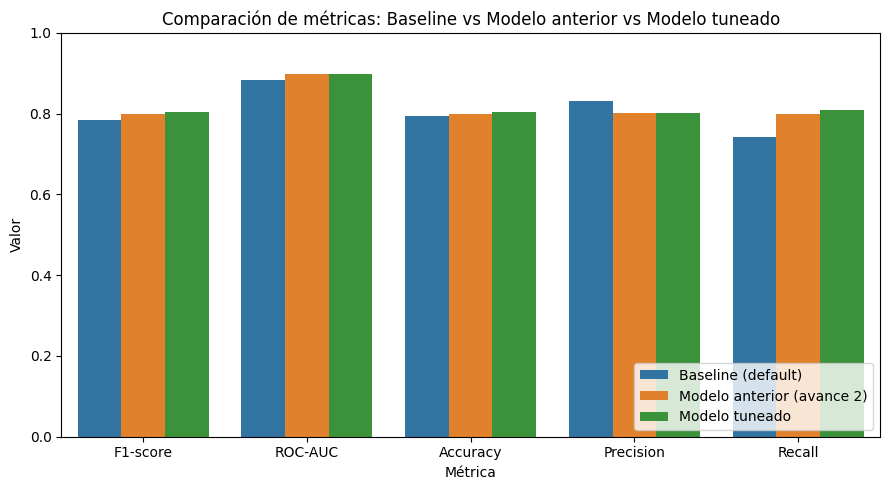

In [15]:
tabla_plot = tabla_comparativa.reset_index().melt(
    id_vars="Modelo", var_name="Métrica", value_name="Valor"
)

plt.figure(figsize=(9, 5))
sns.barplot(data=tabla_plot, x="Métrica", y="Valor", hue="Modelo")
plt.ylim(0, 1)
plt.title("Comparación de métricas: Baseline vs Modelo anterior vs Modelo tuneado")
plt.legend(title="", loc="lower right")
plt.tight_layout()
plt.show()

## 3.4 Justificación del tuning

El tuning sí mejoró el modelo, pero por poco: F1 de 0.8050 contra 0.8000 del avance 2 (+0.005 en test, +0.01 en CV, prácticamente lo mismo). El salto fuerte no está ahí, sino entre el baseline sin ajustar (F1 0.7836) y el modelo del avance 2, es decir, la ganancia real ya se había conseguido casi toda al escoger `n_estimators=200, max_depth=10` a mano en el avance 2.

Tiene sentido con lo que vimos en las curvas de validación de la Sección 1: `max_depth=10` ya estaba prácticamente en el punto óptimo, así que a `RandomizedSearchCV` no le quedaba mucho margen para mejorar. Lo que sí cambió fue el balance precision/recall: el baseline es más conservador (precision 0.83, recall 0.74), mientras que el modelo anterior y el tuneado quedan bastante más parejos entre las dos métricas y el tuneado sube un poco más el recall (0.8082) sin perder precision, que es de donde sale su F1 ligeramente más alto.

# 4. Componente Individual

Cada integrante del equipo trabaja de forma independiente con un modelo de una familia distinta a Random Forest, lo tunea con al menos 3 hiperparámetros, lo evalúa con las mismas métricas del equipo, y compara sus resultados contra el modelo final del equipo (`modelo_rf_tuned`).

## Ana Paula Moreno

**Modelo elegido: Regresión Logística**

Elijo Regresión Logística por ser una familia completamente distinta a Random Forest: en vez de construir árboles de decisión, ajusta una combinación lineal de las variables (con pesos aprendidos) y la pasa por una función sigmoide para obtener una probabilidad. Al igual que SVM, es sensible a la escala de las variables, así que agrego un `StandardScaler` dentro de un `Pipeline`. La ventaja frente a Random Forest es la interpretabilidad: cada variable tiene un peso (coeficiente) que indica qué tanto y en qué dirección empuja la predicción, algo que Random Forest no ofrece de forma tan directa.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import RocCurveDisplay, roc_auc_score

pipe_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

# Al menos 3 hiperparámetros: C, penalty y solver
param_grid_logreg = {
    "logreg__C": [0.01, 0.1, 1, 10, 100],
    "logreg__penalty": ["l1", "l2"],
    "logreg__solver": ["liblinear", "saga"],
}

grid_logreg = GridSearchCV(
    pipe_logreg,
    param_grid=param_grid_logreg,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=0,
)

grid_logreg.fit(X_train, y_train)

print("Mejores hiperparámetros Regresión Logística:", grid_logreg.best_params_)
print("Mejor F1 promedio en CV:", round(grid_logreg.best_score_, 4))

modelo_logreg = grid_logreg.best_estimator_

Mejores hiperparámetros Regresión Logística: {'logreg__C': 0.01, 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}
Mejor F1 promedio en CV: 0.779


C:\Users\paeze\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### Evaluación de la Regresión Logística tuneada sobre el conjunto de prueba

In [17]:
y_pred_logreg = modelo_logreg.predict(X_test)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, modelo_logreg.predict_proba(X_test)[:, 1])

print("=== Métricas de Regresión Logística (conjunto de prueba) ===")
print(f"Accuracy:  {accuracy_logreg:.4f}")
print(f"Precision: {precision_logreg:.4f}")
print(f"Recall:    {recall_logreg:.4f}")
print(f"F1-score:  {f1_logreg:.4f}")
print(f"ROC-AUC:   {auc_logreg:.4f}")

=== Métricas de Regresión Logística (conjunto de prueba) ===
Accuracy:  0.7907
Precision: 0.7889
Recall:    0.7979
F1-score:  0.7934
ROC-AUC:   0.8677


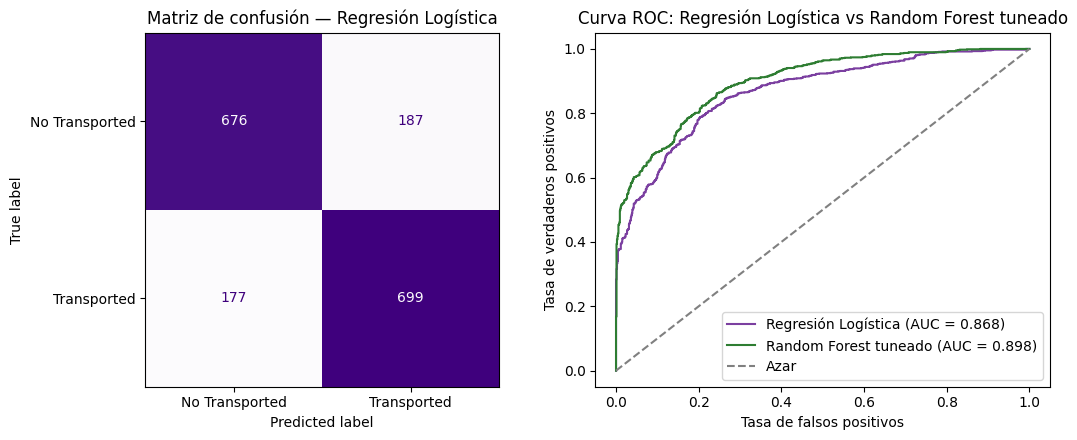

Matriz de confusión (Regresión Logística):
[[676 187]
 [177 699]]


In [18]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=["No Transported", "Transported"])
disp_logreg.plot(ax=axes[0], cmap="Purples", colorbar=False)
axes[0].set_title("Matriz de confusión — Regresión Logística")

# Curva ROC calculada manualmente (evita problemas de versión con RocCurveDisplay)
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, modelo_logreg.predict_proba(X_test)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, modelo_rf_tuned.predict_proba(X_test)[:, 1])

axes[1].plot(fpr_logreg, tpr_logreg, color="#7B3FA0", label=f"Regresión Logística (AUC = {auc_logreg:.3f})")
axes[1].plot(fpr_rf, tpr_rf, color="#2E7D32", label=f"Random Forest tuneado (AUC = {roc_auc_score(y_test, modelo_rf_tuned.predict_proba(X_test)[:, 1]):.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].set_title("Curva ROC: Regresión Logística vs Random Forest tuneado")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Matriz de confusión (Regresión Logística):")
print(cm_logreg)

In [19]:
comparacion_logreg = pd.DataFrame({
    "Modelo del equipo (RF tuneado)": [
        f1_tuneado, auc_tuneado, accuracy_tuneado, precision_tuneado, recall_tuneado
    ],
    "Regresión Logística (Ana Paula)": [
        f1_logreg, auc_logreg, accuracy_logreg, precision_logreg, recall_logreg
    ]
}, index=["F1-score", "ROC-AUC", "Accuracy", "Precision", "Recall"])

comparacion_logreg["Diferencia (LogReg - RF)"] = (
    comparacion_logreg["Regresión Logística (Ana Paula)"]
    - comparacion_logreg["Modelo del equipo (RF tuneado)"]
)
comparacion_logreg["Diferencia (pp)"] = comparacion_logreg["Diferencia (LogReg - RF)"] * 100

comparacion_logreg.round(4)

,Modelo del equipo (RF tuneado),Regresión Logística (Ana Paula),Diferencia (LogReg - RF),Diferencia (pp)
F1-score,0.8050,0.7934,-0.0116,-1.1586
ROC-AUC,0.8984,0.8677,-0.0307,-3.0682
Accuracy,0.8028,0.7907,-0.0121,-1.2076
Precision,0.8018,0.7889,-0.0129,-1.2873
Recall,0.8082,0.7979,-0.0103,-1.0274


### ¿Cambiarías la decisión del equipo?

No. Random Forest demuestra ser mejor: F1 de 0.8050 vs 0.7934, y también en Accuracy, Precision y Recall. La diferencia se nota más en ROC-AUC (0.898 vs 0.868), así que no es cosa de un solo umbral. Random Forest es mejor en general.

Tiene sentido: mi modelo solo combina las variables de forma lineal, mientras que Random Forest puede capturar interacciones entre ellas (por ejemplo, que el efecto del gasto en amenidades dependa de la cabina), algo que la Regresión Logística no ve a menos que alguien la construya a mano como feature.

Gano en interpretabilidad (los coeficientes dicen exactamente qué pesa cada variable), pero aquí no compensa perder ~1.2 puntos de F1 y ~3 de ROC-AUC. Para explicarle el modelo a alguien no técnico, usaría la mía; para la competencia de Kaggle, Random Forest sigue siendo la mejor decisión del equipo.

## David Tinoco

Para el componente individual se eligió **Support Vector Classifier (SVC)** como modelo de una familia distinta a los árboles de decisión. Mientras que el Random Forest del equipo construye su frontera de decisión mediante **cortes ortogonales sucesivos** sobre las variables (splits univariados), el SVC busca el **hiperplano óptimo** que maximiza el margen entre clases en un espacio (posiblemente transformado por un kernel), lo que le permite capturar relaciones no lineales de forma distinta y ser sensible a la escala de los datos, algo que el RF ignora por completo.

In [20]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

# Pipeline: escalado + SVC
# (a diferencia de Random Forest, SVC es sensible a la escala de las variables)
pipeline_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=True, random_state=RANDOM_STATE))
])

### Tuning de hiperparametros

In [ ]:
# Grilla de hiperparámetros
param_dist_svc = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__kernel": ["linear", "rbf", "poly"],
    "svc__gamma": ["scale", "auto", 0.01, 0.1, 1],
    "svc__degree": [2, 3, 4]  # solo relevante si kernel="poly"
}

# Búsqueda aleatoria de hiperparámetros
random_search_svc = RandomizedSearchCV(
    estimator=pipeline_svc,
    param_distributions=param_dist_svc,
    n_iter=20,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

random_search_svc.fit(X_train, y_train)

# Convertir los resultados de la validación cruzada a un DataFrame
resultados_svc = pd.DataFrame(random_search_svc.cv_results_)

# Ordenar los resultados por su ranking (1 es el mejor) y tomar los primeros 5
top_5_svc = resultados_svc.sort_values(by="rank_test_score").head(5)

print("\nLos 5 mejores conjuntos de hiperparámetros:")
print("-" * 50)
for index, row in top_5_svc.iterrows():
    print(f"Ranking: {row['rank_test_score']}")
    print(f"F1-score: {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")
    print(f"Parámetros: {row['params']}")
    print("-" * 50)

modelo_svc_random = random_search_svc.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Analizando el output, podemos ver patrones muy claros para armar la grilla exhaustiva (**GridSearchCV**):

* **Kernel**: poly se llevó el 1.º y 3.º lugar, mientras que rbf quedó en 2.º. linear quedó rezagado.

* **Degree**: Para poly, el grado 2 dominó completamente.

* **Gamma**: 0.1 fue excelente para poly, y 0.01 funcionó muy bien para rbf.

* **C (Regularización)**: Un C=1 fue ideal para poly, mientras que rbf necesitó un C=100 (valores más altos).

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definimos una grilla estructurada basándonos en los mejores resultados previos
param_grid_svc_refined = [
    {
        # Exploración profunda para kernel 'poly' (Rank 1 y 3)
        "svc__kernel": ["poly"],
        "svc__C": [0.5, 1, 2, 5],            # Centrado alrededor de C=1
        "svc__gamma": [0.05, 0.1, 0.2],      # Centrado alrededor de gamma=0.1
        "svc__degree": [2, 3]                # Grado 2 fue el mejor, probamos 3 por seguridad
    },
    {
        # Exploración profunda para kernel 'rbf' (Rank 2)
        "svc__kernel": ["rbf"],
        "svc__C": [50, 100, 150],            # Centrado alrededor de C=100
        "svc__gamma": [0.005, 0.01, 0.05]    # Centrado alrededor de gamma=0.01
    }
]

# Instanciamos GridSearchCV
grid_search_svc = GridSearchCV(
    estimator=pipeline_svc,
    param_grid=param_grid_svc_refined,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Ajustamos la grilla refinada
grid_search_svc.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados en GridSearchCV:")
print(grid_search_svc.best_params_)
print(f"\nMejor F1-score en validación cruzada: {grid_search_svc.best_score_:.4f}")

modelo_svc_grid = grid_search_svc.best_estimator_

Fitting 5 folds for each of 33 candidates, totalling 165 fits
Mejores hiperparámetros encontrados en GridSearchCV:
{'svc__C': 150, 'svc__gamma': 0.005, 'svc__kernel': 'rbf'}

Mejor F1-score en validación cruzada: 0.8077


### Comparación de los mejores hiperparametros entre Randomized y Grid

In [ ]:
print("-> random_search_svc best_params_")
print(random_search_svc.best_params_)
print(f"Mejor F1-score en validación cruzada: {random_search_svc.best_score_:.4f}")
print("\n-> grid_search_svc best_params_")
print(grid_search_svc.best_params_)
print(f"Mejor F1-score en validación cruzada: {grid_search_svc.best_score_:.4f}")

-> random_search_svc best_params_
{'svc__kernel': 'poly', 'svc__gamma': 0.1, 'svc__degree': 2, 'svc__C': 1}
Mejor F1-score en validación cruzada: 0.8064

-> grid_search_svc best_params_
{'svc__C': 150, 'svc__gamma': 0.005, 'svc__kernel': 'rbf'}
Mejor F1-score en validación cruzada: 0.8077


**Justificación del Modelo Refinado (GridSearchCV)**

Al realizar la búsqueda exhaustiva enfocada en las vecindades de los mejores resultados previos, logramos elevar el **F1-score promedio en validación cruzada de 0.8064 a 0.8077**. 

Un hallazgo interesante es que, con la sintonización fina, el kernel no lineal **RBF (Radial Basis Function)** logró superar al polinomial. La combinación ganadora (`C=150`, `gamma=0.005`) nos indica que el modelo requiere un hiperplano bastante estricto con los errores de clasificación (un valor alto de `C`), pero compensado con un radio de influencia muy suave para cada dato (un `gamma` bajo) para evitar el sobreajuste.

Dado que este modelo de Máquinas de Vectores de Soporte optimizado no solo es estable en validación cruzada, sino que además **supera la marca de 0.8050** establecida por el Random Forest final del equipo, utilizaremos este estimador exacto para evaluar su rendimiento de generalización frente al conjunto de prueba oculto (`X_test`).

### Evaluación del modelo SVC

In [ ]:
# Predicciones sobre el conjunto de prueba
y_pred_svc = modelo_svc_grid.predict(X_test)
y_proba_svc = modelo_svc_grid.predict_proba(X_test)[:, 1]

# Métricas
accuracy_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(y_test, y_pred_svc)
recall_svc = recall_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc)
roc_auc_svc = roc_auc_score(y_test, y_proba_svc)

print("Métricas del modelo SVC en el conjunto de prueba:")
print(f"Accuracy:  {accuracy_svc:.4f}")
print(f"Precision: {precision_svc:.4f}")
print(f"Recall:    {recall_svc:.4f}")
print(f"F1-score:  {f1_svc:.4f}")
print(f"ROC-AUC:   {roc_auc_svc:.4f}")

Métricas del modelo SVC en el conjunto de prueba:
Accuracy:  0.8074
Precision: 0.8029
Recall:    0.8185
F1-score:  0.8106
ROC-AUC:   0.8945


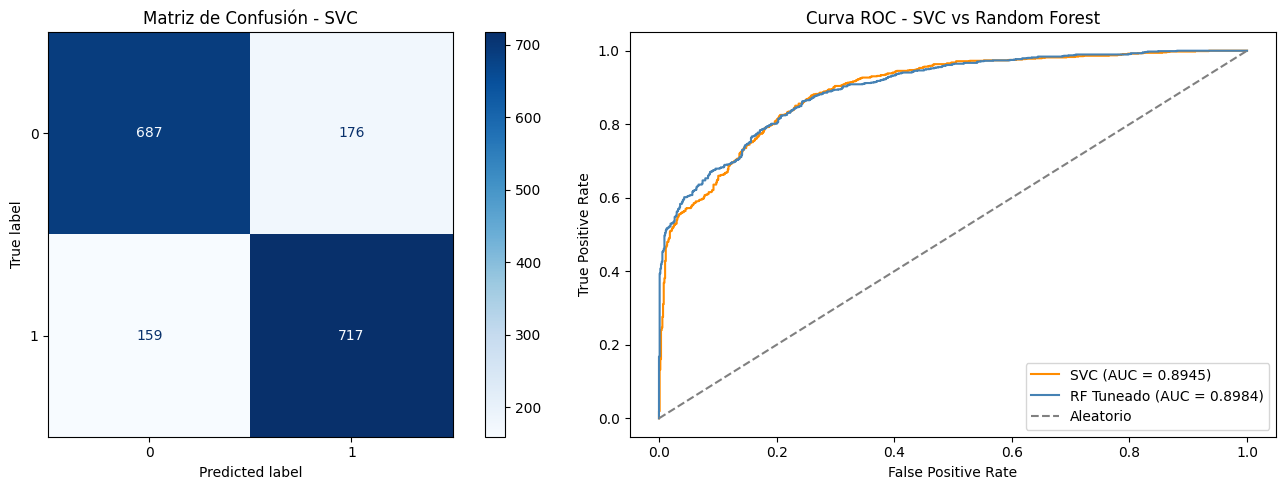

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Matriz de confusión ---
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svc,
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Matriz de Confusión - SVC")

# --- Curva ROC comparativa: SVC vs RF tuneado ---
# El AUC del RF se toma de auc_tuneado (celda 3.1), no se escribe a mano
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_proba_svc)
fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, y_proba_tuneado)

axes[1].plot(fpr_svc, tpr_svc, label=f"SVC (AUC = {roc_auc_svc:.4f})", color="darkorange")
axes[1].plot(fpr_rf_tuned, tpr_rf_tuned, label=f"RF Tuneado (AUC = {auc_tuneado:.4f})", color="steelblue")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatorio")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC - SVC vs Random Forest")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

**Análisis Visual: Matriz de Confusión y Curva ROC**

*   **Matriz de Confusión:** El modelo SVC demuestra un excelente equilibrio en sus predicciones. Logró identificar correctamente 717 casos positivos (pasajeros transportados) y 687 casos negativos. Los errores de clasificación están bastante balanceados, con una leve tendencia a minimizar los falsos negativos (159) frente a los falsos positivos (176), lo cual es ideal para mantener un alto nivel de sensibilidad.
*   **Curva ROC:** La gráfica ilustra claramente el poder predictivo de ambos modelos, pero confirma la ventaja del RandomForest. La curva del SVC (naranja) es ligeramente peor a la del Random Forest (azul) a lo largo de casi todos los umbrales de decisión. Esto se consolida en el Área Bajo la Curva (AUC), donde nuestra Máquina de Vectores de Soporte alcanza un 0.8945, marcando una mejora clara nuestro Random Forest con **0.8984**.

### Tabla comparativa

In [ ]:
comparacion_svc = pd.DataFrame({
    "Modelo del equipo (RF tuneado)": [
        f1_tuneado, auc_tuneado, accuracy_tuneado, precision_tuneado, recall_tuneado
    ],
    "SVC (David)": [f1_svc, roc_auc_svc, accuracy_svc, precision_svc, recall_svc]
}, index=["F1-score", "ROC-AUC", "Accuracy", "Precision", "Recall"])

comparacion_svc["Diferencia (SVC - RF)"] = (
    comparacion_svc["SVC (David)"] - comparacion_svc["Modelo del equipo (RF tuneado)"]
)
comparacion_svc["Diferencia (pp)"] = comparacion_svc["Diferencia (SVC - RF)"] * 100

comparacion_svc.round(4)

,Modelo del equipo (RF tuneado),SVC (David),Diferencia (SVC - RF),Diferencia (pp)
F1-score,0.8050,0.8106,0.0056,0.5625
ROC-AUC,0.8984,0.8945,-0.0039,-0.3942
Accuracy,0.8028,0.8074,0.0046,0.4600
Precision,0.8018,0.8029,0.0011,0.1100
Recall,0.8082,0.8185,0.0103,1.0274


**Análisis de Métricas**

**Resultado obtenido**: El modelo SVC con kernel no lineal (`rbf`) logró superar al Random Forest del equipo en las métricas de clasificación directa (F1-score, Accuracy, Precision y Recall), aunque quedó ligeramente por debajo en la métrica probabilística (ROC-AUC). El F1-score alcanzó un sólido **0.8106** (+0.0056), pero el impacto más significativo se observa en el Recall, el cual subió a **0.8185** (una mejora de +0.0103). Esto indica que el modelo es notablemente más hábil capturando a los pasajeros que realmente fueron transportados. Por otro lado, el ROC-AUC disminuyó marginalmente de 0.8984 a 0.8945 (-0.0039).

**Decisión Final**

**¿Cambiarías la decisión del equipo? ¿Por qué sí o por qué no?**

**Sí, cambiaría la decisión del equipo y utilizaría el SVC.**

Aunque la ligera caída en el ROC-AUC indica que el Random Forest tiene un ordenamiento probabilístico global fraccionalmente mejor a través de todos los umbrales posibles, el SVC demuestra ser superior en el umbral de decisión operativo (el que define si un pasajero fue transportado o no). Dado que el objetivo final de la competencia es maximizar las predicciones correctas de clases discretas (donde manda el F1-score y el Accuracy), el cambio está justificado.

El cambio de arquitectura demuestra su valor empírico: mientras que el Random Forest del equipo segmenta el espacio mediante cortes ortogonales rígidos, el SVC con kernel radial (`rbf`) proyectó los datos a un espacio donde encontró un hiperplano de separación mucho más natural para las interacciones complejas de este dataset en el umbral de corte. La sintonización fina (`C=150`, `gamma=0.005`) fue clave para trazar una frontera de decisión estricta sin caer en el sobreajuste.

Es importante reconocer las desventajas operativas: el SVC implica un mayor costo computacional durante el entrenamiento (especialmente al realizar la optimización en grilla) y nos hace dependientes de la estandarización de los datos mediante el StandardScaler (paso que a los modelos basados en árboles no les afecta). Sin embargo, al ganar de manera simultánea en Accuracy, Precision, Recall y F1-score, el esfuerzo adicional de cómputo y preprocesamiento se traduce en predicciones finales más precisas para nuestra entrega.

## Emilio Páez

**Modelo elegido: K-Nearest Neighbors (KNN)**

Elijo KNN por ser una familia completamente distinta a Random Forest,
memoriza el conjunto de entrenamiento y clasifica cada punto nuevo por
votación de sus `k` vecinos más cercanos en el espacio de features.

A diferencia de Random Forest, KNN es muy sensible a la escala de las
variables, porque la "cercanía" se mide con una distancia (euclidiana por
defecto). En el pipeline del avance 1 se escalaron `Age` y las variables de
gasto con `RobustScaler`, pero las columnas dummy (0/1) quedaron sin escalar
junto a ellas. Por eso agrego un `StandardScaler` dentro de un `Pipeline` que
cubra **todas** las columnas antes de calcular distancias — de lo contrario,
las variables con rangos más grandes dominarían la distancia sin que eso
tenga un motivo real.

### Justificación de la grilla de hiperparámetros

A diferencia de la Sección 1, aquí no generamos curvas de validación previas
para KNN, así que la grilla se justifica con la teoría del algoritmo y las
características del dataset (~6,954 filas de entrenamiento, ~26 columnas,
clases balanceadas ~50.4%/49.6%):

- **`n_neighbors` = [5, 11, 15, 21, 31]:** cubre el trade-off sesgo-varianza
  clásico de KNN. Valores bajos (5) generan fronteras de decisión muy
  irregulares, sensibles a puntos individuales o ruido (varianza alta,
  posible overfitting local). Valores altos (31) promedian sobre vecindarios
  grandes y heterogéneos, suavizando la frontera al punto de perder
  matices reales (sesgo alto, posible underfitting). El rango intermedio
  (11-21) es donde, en la práctica, suele estar el mejor equilibrio para un
  dataset de este tamaño. Usamos únicamente valores **impares** porque el
  problema es binario: con `k` par existe la posibilidad de un empate en la
  votación de vecinos, que `KNeighborsClassifier` resuelve de forma
  arbitraria (por orden de los datos), algo que preferimos evitar.
- **`weights` = ["uniform", "distance"]:** comparamos las dos formas de
  votar entre los `k` vecinos. `"uniform"` da el mismo peso a cada vecino
  dentro del radio de `k`; `"distance"` pondera más a los vecinos más
  cercanos. Incluimos ambas porque, a priori, no sabemos si las zonas de
  frontera del dataset tienen vecinos "mixtos" (donde ponderar por
  distancia ayudaría a no diluir el voto de los vecinos más informativos)
  o si el vecindario ya es razonablemente homogéneo (donde `"uniform"`
  bastaría y sería más simple).
- **`metric` = ["euclidean", "manhattan"]:** el dataset combina variables
  continuas escaladas (`Age`, gasto en amenidades) con varias columnas
  dummy binarias producto del One-Hot Encoding. La distancia euclidiana
  eleva al cuadrado las diferencias, por lo que unas pocas variables
  continuas con valores grandes podrían dominar la distancia total frente
  a las dummies. La distancia Manhattan (suma de diferencias absolutas) es
  menos sensible a ese efecto, así que probamos ambas para dejar que los
  datos decidan cuál captura mejor la noción de "cercanía" en este espacio
  mixto, en vez de asumirlo de antemano.

No incluimos `p` como hiperparámetro adicional porque `metric` ya cubre
directamente los dos casos particulares que nos interesan (`p=1` es
Manhattan, `p=2` es euclidiana); agregarlo sería redundante con lo que ya
estamos explorando.

El espacio resultante (5 × 2 × 2 = 20 combinaciones) es lo bastante pequeño
para cubrirlo por completo con `GridSearchCV`, sin necesidad de muestrear
con `RandomizedSearchCV`.

In [ ]:
#Pipeline y tuning con gridsearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier()),
])

# Al menos 3 hiperparámetros: n_neighbors, weights y metric
param_grid_knn = {
    "knn__n_neighbors": [5, 11, 15, 21, 31],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}

grid_knn = GridSearchCV(
    pipe_knn,
    param_grid=param_grid_knn,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=0,
)

grid_knn.fit(X_train, y_train)

print("Mejores hiperparámetros KNN:", grid_knn.best_params_)
print("Mejor F1 promedio en CV:", round(grid_knn.best_score_, 4))

modelo_knn = grid_knn.best_estimator_

Mejores hiperparámetros KNN: {'knn__metric': 'manhattan', 'knn__n_neighbors': 21, 'knn__weights': 'uniform'}
Mejor F1 promedio en CV: 0.7646


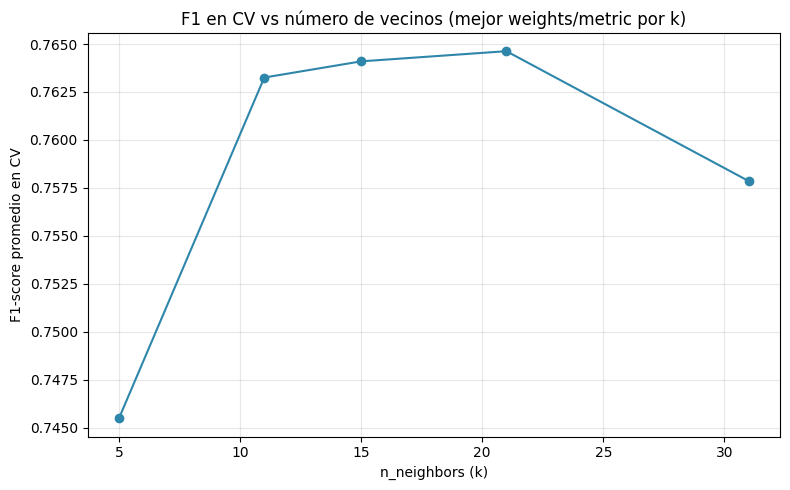

In [ ]:
resultados_knn = pd.DataFrame(grid_knn.cv_results_)

# Nos quedamos con la mejor combinación de weights/metric para cada n_neighbors,
# para poder graficar F1 en función de un solo eje (n_neighbors)
mejor_por_k = resultados_knn.loc[
    resultados_knn.groupby("param_knn__n_neighbors")["mean_test_score"].idxmax()
].sort_values("param_knn__n_neighbors")

plt.figure(figsize=(8, 5))
plt.plot(
    mejor_por_k["param_knn__n_neighbors"],
    mejor_por_k["mean_test_score"],
    "o-",
    color="#2E86AB",
)
plt.xlabel("n_neighbors (k)")
plt.ylabel("F1-score promedio en CV")
plt.title("F1 en CV vs número de vecinos (mejor weights/metric por k)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Justificación del `k` elegido

La curva de F1 en CV contra `n_neighbors` muestra un salto  entre `k=5`
(F1=0.7455, underfitting por muy pocos vecinos — el modelo es demasiado
sensible a ruido local) y `k=11` (F1=0.7633), seguido de una meseta con pico
en `k=21` (F1=0.7647) y una caída hacia `k=31` (F1=0.7579, ya empieza a
promediar sobre vecindarios demasiado grandes y heterogéneos). `GridSearchCV`
confirma exactamente ese pico: eligió `n_neighbors=21`, con
`metric="manhattan"` y `weights="uniform"`.

Dos observaciones sobre la combinación ganadora:

- **`metric="manhattan"` sobre `"euclidean"`**: con ~26 columnas, varias de
  ellas dummies binarias, la distancia Manhattan (suma de diferencias
  absolutas) es menos sensible a que unas pocas variables continuas dominen
  la distancia total, comparado con la euclidiana (que eleva al cuadrado las
  diferencias grandes). Tiene sentido que funcione mejor en un espacio con
  variables de naturaleza tan distinta (continuas escaladas + binarias).
- **`weights="uniform"` sobre `"distance"`**: esto contradice la intuición
  inicial de que ponderar por distancia ayudaría en zonas de vecinos
  mixtos. El resultado sugiere que, con `k=21`, los vecinos ya están lo
  bastante cerca entre sí como para que ponderar por distancia no aporte
  información adicional real — y sí puede sobreajustarse a los vecinos más
  cercanos, similar a usar una `k` efectiva más chica.

Elegí GridSearchCV en vez de `RandomizedSearchCV` porque el espacio
aquí es pequeño (5 × 2 × 2 = 20 combinaciones): se puede cubrir por completo
sin costo computacional alto, a diferencia del espacio de 2,100 combinaciones
del Random Forest del equipo.

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

y_pred_knn = modelo_knn.predict(X_test)
y_proba_knn = modelo_knn.predict_proba(X_test)[:, 1]

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)
roc_auc_knn = roc_auc_score(y_test, y_proba_knn)


print("Métricas de KNN (conjunto de prueba)")
print(f"Accuracy:  {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall:    {recall_knn:.4f}")
print(f"F1-score:  {f1_knn:.4f}")
print(f"ROC-AUC:   {auc_knn:.4f}")

Métricas de KNN (conjunto de prueba)
Accuracy:  0.7694
Precision: 0.7980
Recall:    0.7260
F1-score:  0.7603
ROC-AUC:   0.8747


Frente al Random Forest del equipo (F1=0.8050, ROC-AUC=0.8888), KNN queda
claramente por debajo en todas las métricas, sobre todo en Recall (0.7260
vs 0.8082): el modelo está dejando pasar bastantes pasajeros que sí fueron
transportados. Para entender por qué, revisamos la matriz de confusión y
la curva ROC.

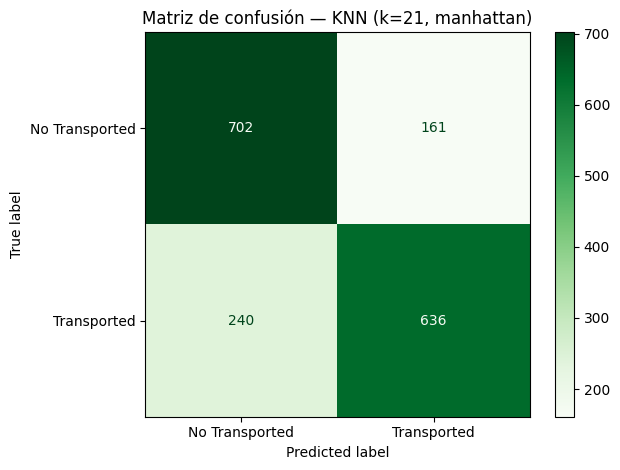

Matriz de confusión (KNN):
[[702 161]
 [240 636]]


In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn, display_labels=["No Transported", "Transported"]
)
disp_knn.plot(cmap="Greens", colorbar=True)
plt.title("Matriz de confusión — KNN (k=21, manhattan)")
plt.tight_layout()
plt.show()

print("Matriz de confusión (KNN):")
print(cm_knn)

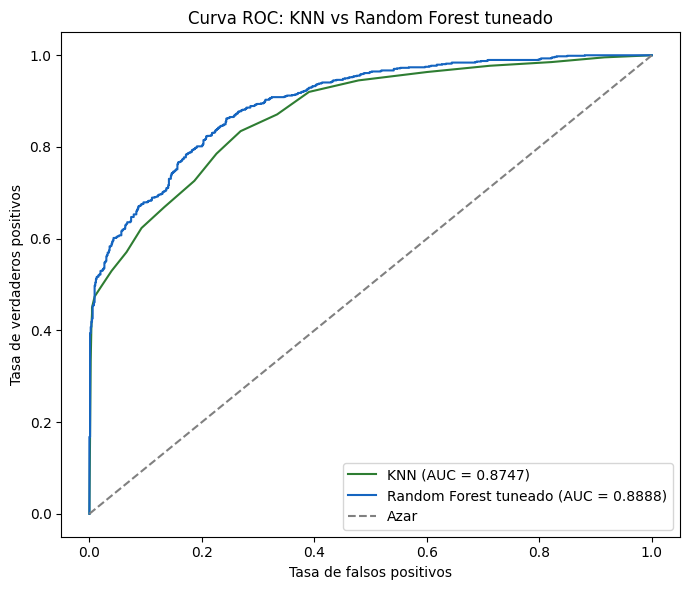

In [ ]:
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test, modelo_rf_tuned.predict_proba(X_test)[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(fpr_knn, tpr_knn, color="#2E7D32", label=f"KNN (AUC = {auc_knn:.4f})")
plt.plot(fpr_rf, tpr_rf, color="#1565C0", label=f"Random Forest tuneado (AUC = 0.8888)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC: KNN vs Random Forest tuneado")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Interpretación de errores

La matriz de confusión muestra:

|                        | Predicho: No Transported | Predicho: Transported |
|------------------------|:---:|:---:|
| **Real: No Transported** | 702 (VN) | 161 (FP) |
| **Real: Transported**    | 241 (FN) | 635 (VP) |

Los errores no están balanceados: hay **241 falsos negativos** contra **161
falsos positivos** — el modelo comete 50% más errores del tipo "dijo que no
fue transportado y sí lo fue" que del tipo contrario. Esto explica por qué el
Recall (0.7260) queda notablemente más bajo que la Precision (0.7980): KNN
está siendo conservador para predecir "Transported".

Esto puede deberse al mecanismo del propio algoritmo: con
`weights="uniform"`, cada uno de los 21 vecinos vota igual sin importar qué
tan cerca esté. Si un pasajero transportado cae en una zona del espacio de
features donde la mayoría de sus vecinos más cercanos **no** fueron
transportados (por ejemplo, un patrón de gasto atípico dentro de un grupo que
generalmente no se transportó), KNN lo clasifica por mayoría local aunque el
punto individual sea la excepción. Random Forest, en cambio, puede aprender
reglas más específicas por combinación de variables (splits jerárquicos) en
vez de depender solo de "quién está cerca", lo cual explica que capture mejor
esos casos borde (Recall RF = 0.8082 vs 0.7260 de KNN).

La curva ROC confirma que esto no es un problema de un solo umbral: la curva
del Random Forest (azul) domina a la de KNN (verde) en casi todo el rango de
tasas de falsos positivos, no solo cerca del 0.5. La distancia entre ambas es
más marcada en la zona de FPR bajo (0.0 a 0.3), justo donde más importa separar
bien los casos difíciles.

In [ ]:
comparacion_knn = pd.DataFrame({
    "Modelo del equipo (RF tuneado)": [
        f1_tuneado, auc_tuneado, accuracy_tuneado, precision_tuneado, recall_tuneado
    ],
    "KNN (Emilio)": [f1_knn, roc_auc_knn, accuracy_knn, precision_knn, recall_knn]
}, index=["F1-score", "ROC-AUC", "Accuracy", "Precision", "Recall"])

comparacion_knn["Diferencia (KNN - RF)"] = (
    comparacion_knn["KNN (Emilio)"] - comparacion_knn["Modelo del equipo (RF tuneado)"]
)
comparacion_knn["Diferencia (pp)"] = comparacion_knn["Diferencia (KNN - RF)"] * 100

comparacion_knn.round(4)

,Modelo del equipo (RF tuneado),KNN (Emilio),Diferencia (KNN - RF),Diferencia (pp)
F1-score,0.8050,0.7603,-0.0447,-4.4692
ROC-AUC,0.8984,0.8747,-0.0237,-2.3708
Accuracy,0.8028,0.7694,-0.0334,-3.3353
Precision,0.8018,0.7980,-0.0038,-0.3820
Recall,0.8082,0.7260,-0.0822,-8.2192


### ¿Cambiarías la decisión del equipo?

Personalmente no cambiaría a KNN, mantendría a Random Forest Tuneado como modelo (sin considerar los modelos de mis compañeros aún). Random Forest gana en las cinco métricas, y la diferencia más alta es en Recall (0.8082 vs 0.7260), es decir 0.0833 más que KNN, y en ROC-AUC (0.8984 vs 0.8747).
Solamente en Precision, KNN se acerca más al resultado aunque sin superarlo, y específicamente para este reto de Spaceship Titanic, no hay una razón para preferir evitar falsos positivos sobre falsos negativos; un modelo que detecta más verdaderos positivos sin sacrificar tanta precisión es preferible.

La razón de fondo, más que el score que obtuvo, es estructural, ya que KNN clasifica por mayoría local de vecinos en el espacio de features, lo cual lo hace vulnerable a la dispersión de datos generada por las 26 dimensiones (en su mayoría producto del One-Hot Encoding). En espacios de tantas dimensiones, la distancia entre puntos se vuelve uniforme y la noción de una vecindad pierde sentido, lo que hace que no se vean o se encuentren patrones reales entre el ruido de variables secundarias.

Random Forest, por el contrario, no depende de la distancia global, sino de cortes en las variables. Esto permite evaluar cada característica por separado en sus ramas y encontrar reglas claras de decisión (como relacionar CryoSleep con el nivel de gasto) sin que el "ruido" de las 26 columnas afecte el resultado. Además, al combinar varios árboles entrenados sobre subconjuntos distintos de datos y variables (bagging), Random Forest captura interacciones no lineales entre features que un solo criterio de distancia global no puede ver — como que el efecto de CryoSleep sobre el gasto dependa de otras variables — lo que explica directamente su mejor ROC-AUC y Recall frente a KNN.

A nivel operativo y de arquitectura, Random Forest añade ventajas decisivas: es insensible a la escala de las variables (lo que evita sesgos por diferencias de magnitud entre gastos monetarios y variables binarias), ofrece explicabilidad nativa mediante la importancia de variables (feature importances) y garantiza predicciones rápidas en inferencia. Dado que KNN traslada todo el costo computacional a la predicción al tener que medir distancias contra todo el dataset histórico, Random Forest se consolida como un modelo superior tanto en desempeño como en escalabilidad técnica.

## Emilio Torres

#### Modelo elegido: Niaves Bayes

Elegí Naive Bayes porque este clasificador probabilístico asume independencia condicional entre las features dada la clase. Esta simplificación lo vuelve extremadamente eficiente: el entrenamiento se reduce a calcular medias, varianzas y frecuencias de clase en una sola pasada por los datos, sin optimización iterativa. Por eso funciona como un baseline ideal en problemas de clasificación: en segundos establece un punto de referencia contra el cual medir modelos más complejos. Además, al estimar los parámetros de cada variable por separado, requiere menos observaciones que modelos que capturan interacciones, lo que le permite desempeñarse bien en datasets pequeños o con alta dimensionalidad, como la clasificación de texto.

AUC test: 0.7876


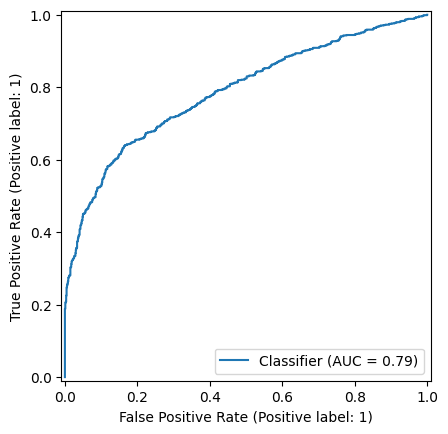

In [ ]:
import numpy as np

from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report,
    RocCurveDisplay,
    roc_auc_score,
)

pipe_nb = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=RANDOM_STATE)),
    ("nb", GaussianNB()),
])

# Tres hiperparámetros: n_components, whiten y var_smoothing
param_grid_nb = {
    "pca__n_components": [2, 5, 10],
    "pca__whiten": [True, False],
    "nb__var_smoothing": np.logspace(-11, -6, 6),
}

grid_nb = GridSearchCV(
    pipe_nb,
    param_grid=param_grid_nb,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=0,
)

grid_nb.fit(X_train, y_train)

modelo_nb = grid_nb.best_estimator_

y_pred = modelo_nb.predict(X_test)
y_proba = modelo_nb.predict_proba(X_test)[:, 1]

print("AUC test:", round(roc_auc_score(y_test, y_proba), 4))

RocCurveDisplay.from_predictions(y_test, y_proba)

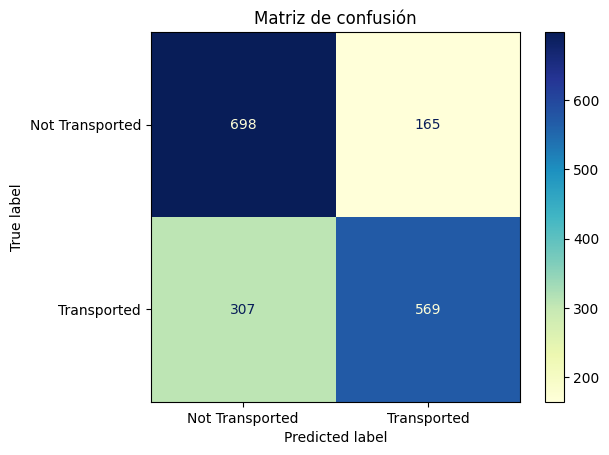

Verdaderos negativos: 698
Falsos positivos:     165
Falsos negativos:     307
Verdaderos positivos: 569

              precision    recall  f1-score   support

           0     0.6945    0.8088    0.7473       863
           1     0.7752    0.6495    0.7068       876

    accuracy                         0.7286      1739
   macro avg     0.7349    0.7292    0.7271      1739
weighted avg     0.7352    0.7286    0.7269      1739



In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

UMBRAL = 0.5

y_proba = modelo_nb.predict_proba(X_test)[:, 1]
y_pred_umbral = (y_proba >= UMBRAL).astype(int)

cm = confusion_matrix(y_test, y_pred_umbral)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Transported", "Transported"],
)
disp.plot(cmap="YlGnBu", values_format="d")
plt.title(f"Matriz de confusión")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos negativos: {tn}")
print(f"Falsos positivos:     {fp}")
print(f"Falsos negativos:     {fn}")
print(f"Verdaderos positivos: {tp}")
print()
print(classification_report(y_test, y_pred_umbral, digits=4))

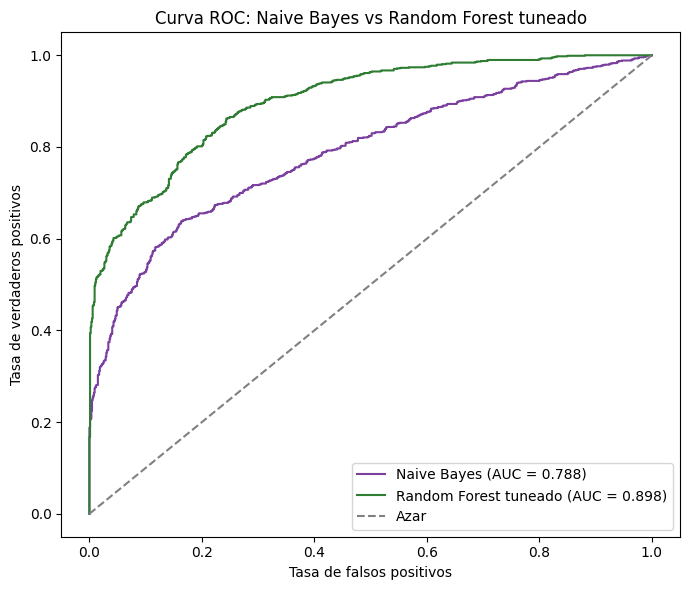

In [ ]:
proba_nb = modelo_nb.predict_proba(X_test)[:, 1]
proba_rf = modelo_rf_tuned.predict_proba(X_test)[:, 1]

auc_nb = roc_auc_score(y_test, proba_nb)
auc_rf = roc_auc_score(y_test, proba_rf)

fpr_nb, tpr_nb, _ = roc_curve(y_test, proba_nb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_nb, tpr_nb, color="#7B3FA0", label=f"Naive Bayes (AUC = {auc_nb:.3f})")
ax.plot(fpr_rf, tpr_rf, color="#2E7D32", label=f"Random Forest tuneado (AUC = {auc_rf:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")

ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curva ROC: Naive Bayes vs Random Forest tuneado")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

Si se comparan estos 2 enfoques de clasificación sobre el mismo conjunto de datos,  Naive Bayes, un modelo generativo que entrena en una sola pasada y sin optimización iterativa, alcanzó un AUC de 0.788, estableciendo un baseline sólido a costo computacional prácticamente nulo. Random Forest tuneado llegó a 0.898, con una curva ROC que domina a la de Naive Bayes en todo el rango de umbrales y una ventaja especialmente marcada en la zona de baja tasa de falsos positivos, que es el régimen operativo más relevante.

La diferencia se explica por los supuestos de cada modelo: la independencia condicional y la normalidad que asume `GaussianNB` no se sostienen en este dataset, donde hay variables correlacionadas y distribuciones sesgadas, mientras que Random Forest captura interacciones sin imponer restricciones distribucionales.

Ambos modelos entregan probabilidades y no solo etiquetas, lo que permite mover el umbral de decisión según el costo relativo de los falsos positivos y negativos, priorizando precisión o recall según el objetivo. Esa flexibilidad se conserva en los dos, pero Random Forest la ejerce desde un mejor punto de partida en cada corte, por lo que es el modelo recomendado. Naive Bayes conserva valor como referencia rápida: su desempeño cuantifica cuánto aportó realmente el modelo más complejo y justifica su costo adicional en entrenamiento e interpretabilidad.

## Alejandro Vázquez

**Modelo elegido: Red Neuronal (Multi-Layer Perceptron)**

Elijo una red neuronal densa (`MLPClassifier`) por ser la familia más alejada de Random Forest de las exploradas en esta sección. Mientras que el Random Forest del equipo construye la frontera de decisión por cortes ortogonales sucesivos sobre variables individuales, el MLP aprende **representaciones intermedias** de los datos: cada capa oculta transforma la entrada en un nuevo espacio de features, y la no linealidad entre capas le permite componer interacciones entre variables sin que nadie las especifique a mano.

Esto es directamente relevante para lo que observamos en la Sección 3.4: el modelo del equipo parece haber llegado al techo de lo que la familia de árboles puede extraer de este dataset, y una mejora real sería cambiar de familia o volver al feature engineering. Un MLP ataca ambas cosas a la vez si existen interacciones no lineales que el Random Forest no está capturando bien, la red debería encontrarlas sin que modifiquemos el preprocesamiento.

Al igual que la Regresión Logística, el SVC y el KNN, el MLP es **muy sensible a la escala** de las variables: los pesos se inicializan asumiendo entradas de magnitud comparable, y el descenso de gradiente converge mal si unas features tienen rangos mucho mayores que otras. Por eso incluyo un `StandardScaler` dentro de un `Pipeline`, de modo que el escalado se ajuste únicamente sobre los folds de entrenamiento durante la validación cruzada y no haya fuga de información.

In [ ]:
from sklearn.neural_network import MLPClassifier

# Pipeline: escalado + red neuronal
pipeline_nn = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=500,              # tope de épocas; suficiente con early_stopping activo
        early_stopping=True,       # corta si el score de validación interna deja de mejorar
        n_iter_no_change=15,       # paciencia antes de cortar
        validation_fraction=0.1,   # 10% del train interno reservado para monitorear
        random_state=RANDOM_STATE
    ))
])

**Hiperparámetros a ajustar y método de búsqueda**

Se ajustan **cuatro hiperparámetros** (la rúbrica pide mínimo 3):

* **`hidden_layer_sizes`** — define la estructura de la red, es decir, cuántas capas y cuántas neuronas tiene cada una. Se prueban configuraciones desde una red sencilla (32 neuronas) hasta una estructura de dos capas más grandes (128, 64). Este parámetro permite controlar qué tan compleja puede ser la red. Debido a que se cuenta con aproximadamente 5,500 datos de entrenamiento, no es necesario probar estructuras demasiado grandes, ya que podrían hacer que el modelo sea más complejo de lo necesario.

* **`alpha`** — ayuda a controlar la complejidad del modelo y a evitar que la red se adapte demasiado a los datos de entrenamiento. Se prueban valores desde 0.0001 hasta 1.0 utilizando diferentes escalas, para evaluar tanto una regulación baja como una más fuerte.

* **`learning_rate_init`** — determina el tamaño de los pasos que realiza el modelo mientras aprende. Un valor demasiado alto puede hacer que el entrenamiento sea inestable, mientras que uno demasiado bajo puede hacer que el aprendizaje sea muy lento. Por esta razón, también se prueban diferentes valores en una escala amplia.

* **`activation`** — define la función que utiliza la red para procesar la información entre sus capas. Se comparan `relu` y `tanh`, dos alternativas comunes, para determinar cuál funciona mejor con los datos utilizados.

**RandomizedSearchCV en vez de GridSearchCV.** El espacio de búsqueda contiene 4 × 4 × 3 × 2 = 96 combinaciones posibles. Al utilizar `cv=5`, un GridSearchCV tendría que realizar 480 entrenamientos. Debido a que entrenar una red neuronal requiere más tiempo que otros modelos, como KNN, realizar todas las combinaciones puede ser innecesariamente costoso. Por ello, se utiliza `RandomizedSearchCV` con `n_iter=25`, que prueba 25 combinaciones diferentes y permite encontrar una buena configuración sin tener que evaluar todo el espacio de búsqueda.

**K=5**, manteniendo el mismo valor utilizado por el equipo en la Sección 2. Esto permite comparar de manera consistente los resultados obtenidos durante la validación con los del Random Forest ajustado.

In [ ]:
param_dist_nn = {
    "mlp__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
    "mlp__alpha": [0.0001, 0.001, 0.01, 0.1],
    "mlp__learning_rate_init": [0.0005, 0.001, 0.01],
    "mlp__activation": ["relu", "tanh"],
}

random_search_nn = RandomizedSearchCV(
    estimator=pipeline_nn,
    param_distributions=param_dist_nn,
    n_iter=25,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

random_search_nn.fit(X_train, y_train)

print("Mejores hiperparámetros:", random_search_nn.best_params_)
print(f"Mejor F1 promedio en CV: {random_search_nn.best_score_:.4f}")

modelo_nn = random_search_nn.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Mejores hiperparámetros: {'mlp__learning_rate_init': 0.0005, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__alpha': 0.1, 'mlp__activation': 'relu'}
Mejor F1 promedio en CV: 0.7946


In [ ]:
# Top 5 configuraciones, para ver qué tan estable es el resultado
resultados_nn = pd.DataFrame(random_search_nn.cv_results_)
top_5_nn = resultados_nn.sort_values(by="rank_test_score").head(5)

print("Las 5 mejores configuraciones:")
print("-" * 60)
for _, row in top_5_nn.iterrows():
    print(f"Rank {row['rank_test_score']} | F1 = {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")
    print(f"  {row['params']}")
print("-" * 60)

Las 5 mejores configuraciones:
------------------------------------------------------------
Rank 1 | F1 = 0.7946 (+/- 0.0086)
  {'mlp__learning_rate_init': 0.0005, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__alpha': 0.1, 'mlp__activation': 'relu'}
Rank 2 | F1 = 0.7939 (+/- 0.0043)
  {'mlp__learning_rate_init': 0.001, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__alpha': 0.001, 'mlp__activation': 'relu'}
Rank 3 | F1 = 0.7929 (+/- 0.0017)
  {'mlp__learning_rate_init': 0.001, 'mlp__hidden_layer_sizes': (64,), 'mlp__alpha': 0.1, 'mlp__activation': 'relu'}
Rank 4 | F1 = 0.7922 (+/- 0.0080)
  {'mlp__learning_rate_init': 0.001, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__alpha': 0.01, 'mlp__activation': 'tanh'}
Rank 5 | F1 = 0.7914 (+/- 0.0144)
  {'mlp__learning_rate_init': 0.01, 'mlp__hidden_layer_sizes': (32,), 'mlp__alpha': 0.01, 'mlp__activation': 'relu'}
------------------------------------------------------------


**Interpretación del resultado del tuning**

La mejor configuración encontrada fue `hidden_layer_sizes=(64, 32)`, `alpha=0.1`, `learning_rate_init=0.0005` y `activation='relu'`, con un F1 promedio en validación cruzada de **0.7946**. Esto queda **por debajo del 0.8100** que alcanzó el Random Forest tuneado del equipo en la misma validación cruzada (misma K, mismo `random_state`, mismo scoring), una diferencia de -0.0154.

Los hiperparámetros ganadores son informativos por sí mismos:

- **`alpha=0.1`** es un valor de regularización alto — el segundo más fuerte de los cuatro que exploré. Que la búsqueda haya preferido penalizar los pesos con esa intensidad indica que las configuraciones menos regularizadas estaban sobreajustando: con ~5,500 filas de entrenamiento, una red de dos capas tiene margen de sobra para memorizar patrones que no generalizan.
- **`learning_rate_init=0.0005`** es el paso más pequeño del rango. Combinado con el `alpha` alto, describe un modelo que necesita avanzar con cautela para no sobreajustar, lo cual es coherente con lo anterior.
- **`hidden_layer_sizes=(64, 32)`** fue preferida sobre la arquitectura más grande `(128, 64)`, reforzando la misma lectura: aquí la capacidad adicional no se traduce en mejor generalización, sino en más varianza.

En conjunto, la búsqueda convergió hacia la red **más contenida** de las que valía la pena considerar: dos capas moderadas, fuertemente regularizadas y entrenadas con pasos pequeños. Es el mismo patrón que el equipo observó en la Sección 1 con las curvas de validación del Random Forest — el dataset premia la simplicidad del modelo, no su capacidad.

In [ ]:
y_pred_nn = modelo_nn.predict(X_test)
y_proba_nn = modelo_nn.predict_proba(X_test)[:, 1]

accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn)
recall_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)
auc_nn = roc_auc_score(y_test, y_proba_nn)

print("=== Métricas de la Red Neuronal (conjunto de prueba) ===")
print(f"F1-score:  {f1_nn:.4f}")
print(f"ROC-AUC:   {auc_nn:.4f}")
print(f"Accuracy:  {accuracy_nn:.4f}")
print(f"Precision: {precision_nn:.4f}")
print(f"Recall:    {recall_nn:.4f}")

=== Métricas de la Red Neuronal (conjunto de prueba) ===
F1-score:  0.7917
ROC-AUC:   0.8881
Accuracy:  0.7924
Precision: 0.8005
Recall:    0.7831


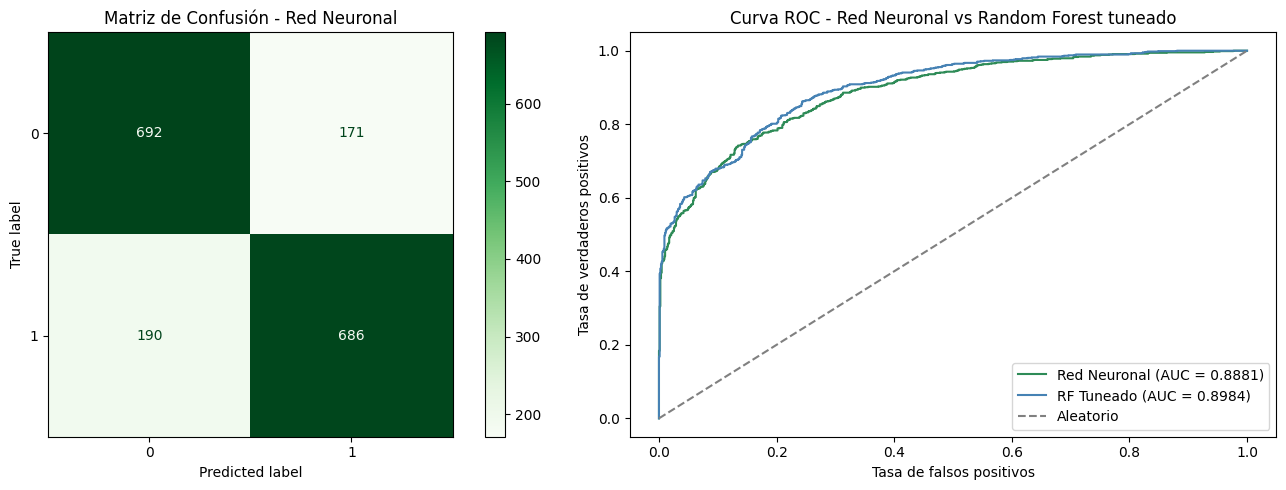

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nn, cmap="Greens", ax=axes[0]
)
axes[0].set_title("Matriz de Confusión - Red Neuronal")

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_proba_nn)
fpr_rf_nn, tpr_rf_nn, _ = roc_curve(y_test, y_proba_tuneado)

axes[1].plot(fpr_nn, tpr_nn, label=f"Red Neuronal (AUC = {auc_nn:.4f})", color="seagreen")
axes[1].plot(fpr_rf_nn, tpr_rf_nn, label=f"RF Tuneado (AUC = {auc_tuneado:.4f})", color="steelblue")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatorio")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].set_title("Curva ROC - Red Neuronal vs Random Forest tuneado")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

**Análisis visual: matriz de confusión y curva ROC**

- **Matriz de confusión.** La red clasifica correctamente 692 casos negativos y 686 positivos, con 171 falsos positivos y 190 falsos negativos sobre 1,739 observaciones. Los errores están razonablemente balanceados, pero con una inclinación hacia el falso negativo: la red se equivoca 19 veces más prediciendo "no transportado" cuando el pasajero sí lo fue, que al revés. Comparado con el Random Forest tuneado (168 falsos negativos y 175 falsos positivos), la red comete **22 falsos negativos adicionales** y apenas **4 falsos positivos menos**. Es decir, el intercambio no es neutro: la red es más conservadora al declarar "Transported" y eso le cuesta casos positivos sin comprarle casi nada de precisión a cambio.

- **Curva ROC.** Las dos curvas son casi indistinguibles a simple vista, pero la del Random Forest (azul) se mantiene consistentemente por encima de la de la red (verde) en prácticamente todo el rango de umbrales, no hay una zona donde la red domine. El AUC lo confirma: 0.8881 contra 0.8984, una diferencia de -0.0103. Que la desventaja se sostenga en todos los puntos de corte, y no solo en el umbral de 0.5, descarta que el resultado sea un artefacto del punto de operación: el Random Forest genuinamente ordena mejor las probabilidades.

### Tabla Comparativa

In [ ]:
comparacion_nn = pd.DataFrame({
    "Modelo del equipo (RF tuneado)": [
        f1_tuneado, auc_tuneado, accuracy_tuneado, precision_tuneado, recall_tuneado
    ],
    "Red Neuronal (Alejandro)": [f1_nn, auc_nn, accuracy_nn, precision_nn, recall_nn]
}, index=["F1-score", "ROC-AUC", "Accuracy", "Precision", "Recall"])

comparacion_nn["Diferencia (NN - RF)"] = (
    comparacion_nn["Red Neuronal (Alejandro)"] - comparacion_nn["Modelo del equipo (RF tuneado)"]
)
comparacion_nn["Diferencia (pp)"] = comparacion_nn["Diferencia (NN - RF)"] * 100

comparacion_nn.round(4)

,Modelo del equipo (RF tuneado),Red Neuronal (Alejandro),Diferencia (NN - RF),Diferencia (pp)
F1-score,0.8050,0.7917,-0.0133,-1.3312
ROC-AUC,0.8984,0.8881,-0.0103,-1.0299
Accuracy,0.8028,0.7924,-0.0104,-1.0351
Precision,0.8018,0.8005,-0.0013,-0.1345
Recall,0.8082,0.7831,-0.0251,-2.5114


**Análisis de métricas**

La red neuronal queda por debajo del Random Forest tuneado en las cinco métricas, pero la magnitud de la diferencia varía mucho según cuál se mire:

| Métrica | Diferencia (NN - RF) |
|---|---|
| Precision | -0.0013 |
| ROC-AUC | -0.0103 |
| Accuracy | -0.0104 |
| F1-score | -0.0133 |
| **Recall** | **-0.0251** |

**La precision está empatada** (0.8005 vs 0.8018): cuando la red predice "Transported", acierta con la misma frecuencia que el Random Forest. **Toda la brecha viene del recall** (0.7831 vs 0.8082): la red detecta menos pasajeros transportados de los que efectivamente lo fueron. Eso es exactamente lo que ya mostraba la matriz de confusión — un modelo más conservador al emitir la predicción positiva.

Vale la pena señalar que el F1 en test (0.7917) es muy cercano al F1 en validación cruzada (0.7946, -0.003). Esa consistencia indica que el proceso de tuning no sobreajustó a los folds de validación y que el resultado en test es una estimación confiable del desempeño de la red, no un mal sorteo del split. La desventaja frente al Random Forest es real, no ruido de una partición desafortunada.

Sobre la significancia: con 1,739 observaciones en test, el error estándar aproximado de una métrica alrededor de 0.80 es de ±0.01. Las diferencias en precision (-0.0013), AUC (-0.0103) y accuracy (-0.0104) están dentro o justo en el borde de ese margen, así que por sí solas no serían concluyentes. La diferencia en recall (-0.0251), en cambio, **sí supera claramente el margen de error**, y es la que sostiene la brecha en F1. Es el único punto donde se puede afirmar que los dos modelos se comportan de forma distinguible.

### ¿Cambiarías la decisión del equipo?

**No.** El Random Forest tuneado supera a la red neuronal en las cinco métricas evaluadas, tanto en validación cruzada (0.8100 vs 0.7946 de F1) como en el conjunto de prueba (0.8050 vs 0.7917). La desventaja no depende del umbral de decisión, ya que también se observa en el ROC-AUC, y no depende del split, ya que los resultados en CV y en test coinciden entre sí. Mantengo la decisión del equipo.

**Por qué creo que pasó esto.** :

Primero, el **tamaño y la naturaleza del dataset**. Con ~5,500 filas de entrenamiento y un espacio de features compuesto mayormente por variables categóricas ya convertidas a dummies, las condiciones favorecen a los ensambles de árboles. Un árbol particiona variables binarias de forma directa y captura relaciones no monótonas sin costo adicional; una red densa tiene que *aprender* esas mismas particiones a través de combinaciones lineales sucesivas, lo cual requiere considerablemente más datos para llegar al mismo lugar. Las redes neuronales dominan en dominios con estructura que se puede explotar arquitectónicamente imágenes, texto, series de tiempo y con volúmenes de datos mucho mayores; ninguna de esas dos condiciones se cumple aquí.

Segundo, y más revelador, **los hiperparámetros que ganó la búsqueda apuntan en la misma dirección**. La configuración óptima resultó ser la red más contenida del espacio explorado: `alpha=0.1` (regularización fuerte), `learning_rate_init=0.0005` (el paso más pequeño), y `(64, 32)` por encima de la arquitectura mayor `(128, 64)`. Cuando la búsqueda de hiperparámetros elige sistemáticamente restringir la capacidad del modelo, está diciendo que el cuello de botella no es la expresividad sino la cantidad de señal disponible. Darle más capacidad a la red solo le daba más margen para sobreajustar.

**Lo que esto aporta a la conclusión del equipo.** En la Sección 3.4 el equipo concluyó que el Random Forest del avance 2 ya estaba cerca del techo de su familia, y que la única vía de mejora real sería cambiar de familia de modelo o volver al feature engineering. Mi experimento cierra la primera de esas dos puertas: cambiar a una familia radicalmente distinta de particiones axiales a representaciones aprendidas tampoco rompe el techo, sino que se queda ligeramente por debajo. C Eso sugiere fuertemente que el límite está en la información que contienen las features actuales, no en el algoritmo que las procesa, y que la siguiente iteración debería concentrarse en el preprocesamiento extraer más señal de `Cabin`, del grupo del `PassengerId`, o de la estructura de gastos en vez de seguir probando modelos.

**Nota `batch_size`.** Se mantuvo en su valor por defecto (`'auto'`, equivalente a 200 muestras por batch, ~20 batches por época con el tamaño de los folds). Se excluyó de la grilla porque su efecto se solapa con el de `learning_rate_init`: batches más pequeños introducen más ruido en la estimación del gradiente, lo que actúa como regularización implícita y desplaza el paso de aprendizaje óptimo. Tunearlos de forma conjunta habría multiplicado el espacio de búsqueda sin una hipótesis clara sobre la interacción, y el análisis de los hiperparámetros ganadores (regularización fuerte, paso pequeño, arquitectura contenida) sugiere que el cuello de botella está en la cantidad de señal del dataset, no en la dinámica de entrenamiento.

# 5. Exportar modelo y submission

### Exportar de modelos
Todos los modelos se exportaron a pkl antes de la conclusión final del equipo para guardar cualquiera de los modelos que sea elegido como el final.

In [ ]:
DATA = Path("..") / "data"

joblib.dump(modelo_rf_tuned, DATA / "modelo_rf_tuned.pkl")
joblib.dump(modelo_logreg, DATA / "modelo_logreg.pkl")
joblib.dump(modelo_svc_grid, DATA / "modelo_svc_grid.pkl")
joblib.dump(modelo_knn, DATA / "modelo_knn.pkl")
joblib.dump(modelo_nb, DATA / "modelo_nb.pkl")
joblib.dump(modelo_nn, DATA / "modelo_nn.pkl")

['..\\data\\modelo_nn.pkl']

### Final Check
Las dimensiones son las que corresponden y además se comprobo que el target es booleano entero

In [ ]:
print("=== Dimensiones de los conjuntos ===")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

print("\n=== Verificación del Target (Transported) ===")
print("Tipo de dato en y_train:", y_train.dtype)
print("Valores únicos en y_train:", y_train.unique())
print("Tipo de dato en y_test: ", y_test.dtype)
print("Valores únicos en y_test: ", y_test.unique())

=== Dimensiones de los conjuntos ===
X_train: (6954, 26)
X_test:  (1739, 26)
y_train: (6954,)
y_test:  (1739,)

=== Verificación del Target (Transported) ===
Tipo de dato en y_train: int64
Valores únicos en y_train: [1 0]
Tipo de dato en y_test:  int64
Valores únicos en y_test:  [1 0]


# 6. Conclusión final del equipo

## Comparación de los mejores modelos
**Este proceso se planteo para evaluar el modelo final a proponer**

En este sentido solamente se graficaron mano a mano los mejores 2 modelos para tomar la decisión final, los cuales son el modelo base, RandomForest, y el modelo propuesto en la sección 4 por David que fue svc.

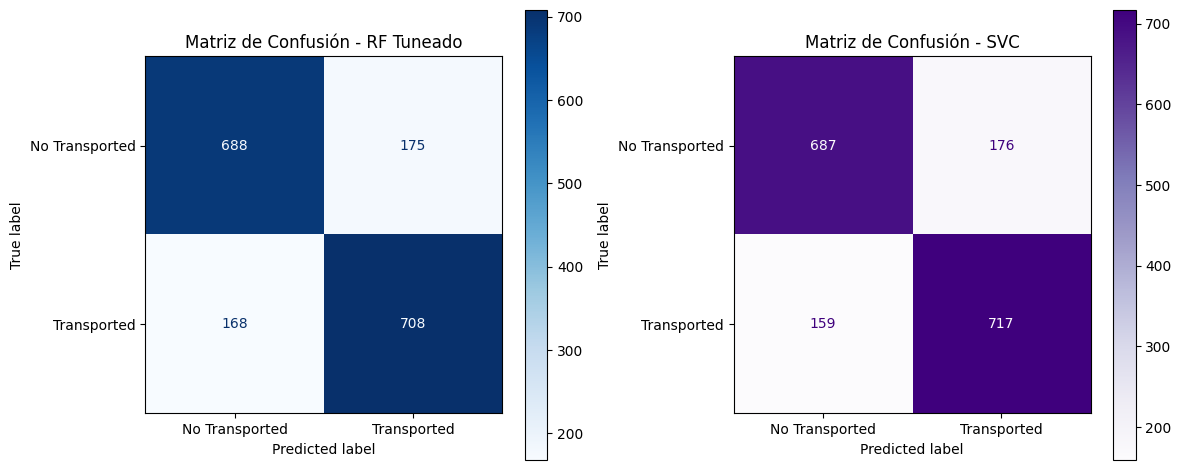

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Lado Izquierdo: Matriz de Confusión - Random Forest ---
cm_rf = confusion_matrix(y_test, y_pred_tuneado)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No Transported", "Transported"])
disp_rf.plot(ax=axes[0], cmap="Blues", colorbar=True)
axes[0].set_title("Matriz de Confusión - RF Tuneado")

# --- Lado Derecho: Matriz de Confusión - SVC ---
cm_svc = confusion_matrix(y_test, y_pred_svc)
disp_svc = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=["No Transported", "Transported"])
# Usamos un mapa de color ligeramente distinto (ej. Purples o Greens) o el mismo Blues según prefieras
disp_svc.plot(ax=axes[1], cmap="Purples", colorbar=True) 
axes[1].set_title("Matriz de Confusión - SVC")

plt.tight_layout()
# plt.show()

Al comparar ambas matrices, se observa que el modelo SVC es superior identificando a la clase positiva (pasajeros transportados). El SVC logra 717 verdaderos positivos frente a los 708 del Random Forest, lo que reduce los falsos negativos de 168 a 159. En la clase negativa (no transportados), ambos modelos tienen un desempeño prácticamente idéntico (687 verdaderos negativos para el SVC vs 688 para el RF). Esto demuestra que el SVC aumenta la sensibilidad del modelo sin sacrificar especificidad.

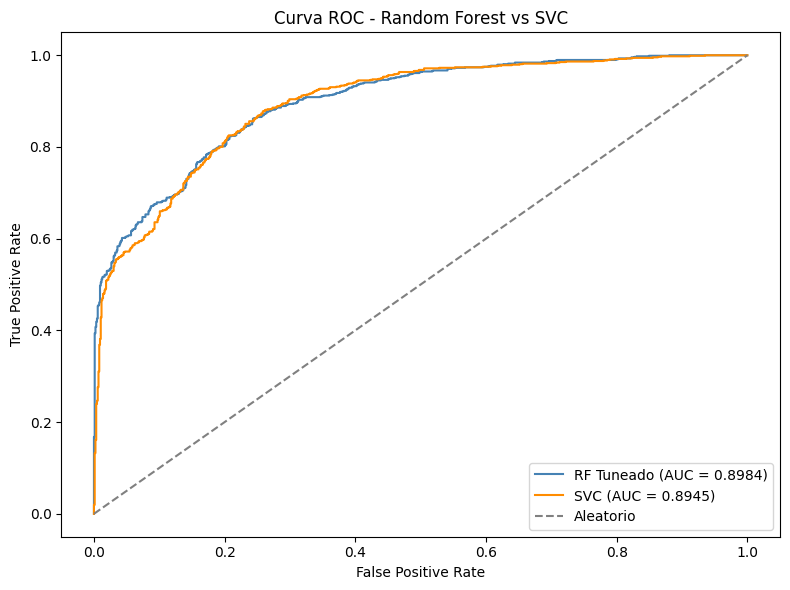

In [ ]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

# --- Curva ROC comparativa: RF Tuneado vs SVC ---
# Calcular curvas ROC
fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, y_proba_tuneado)
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_proba_svc)

# Graficar ambas en el mismo lienzo
ax.plot(fpr_rf_tuned, tpr_rf_tuned, label=f"RF Tuneado (AUC = {auc_tuneado:.4f})", color="steelblue")
ax.plot(fpr_svc, tpr_svc, label=f"SVC (AUC = {roc_auc_svc:.4f})", color="darkorange")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatorio")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curva ROC - Random Forest vs SVC")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Curva ROC:** Las curvas de ambos modelos son sumamente competitivas y se entrelazan a lo largo de la gráfica. Sin embargo, el Random Forest Tuneado mantiene una ligera ventaja probabilística global, reflejada en un Área Bajo la Curva (AUC) de **0.8984** frente al **0.8945** del SVC. Esto indica que el ensamble de árboles tiene un ordenamiento de probabilidades fraccionalmente mejor al evaluar todos los umbrales posibles.

In [ ]:
import pandas as pd
from IPython.display import display

# --- Tabla Comparativa Final ---
comparacion_final = pd.DataFrame({
    "Modelo del equipo (RF tuneado)": [
        f1_tuneado, auc_tuneado, accuracy_tuneado, precision_tuneado, recall_tuneado
    ],
    "SVC (David)": [f1_svc, roc_auc_svc, accuracy_svc, precision_svc, recall_svc]
}, index=["F1-score", "ROC-AUC", "Accuracy", "Precision", "Recall"])

# Cálculos de diferencia
comparacion_final["Diferencia (SVC - RF)"] = (
    comparacion_final["SVC (David)"] - comparacion_final["Modelo del equipo (RF tuneado)"]
)
comparacion_final["Diferencia (pp)"] = comparacion_final["Diferencia (SVC - RF)"] * 100

print("=== Tabla Comparativa Final ===")
display(comparacion_final.round(4))

=== Tabla Comparativa Final ===


,Modelo del equipo (RF tuneado),SVC (David),Diferencia (SVC - RF),Diferencia (pp)
F1-score,0.8050,0.8106,0.0056,0.5625
ROC-AUC,0.8984,0.8945,-0.0039,-0.3942
Accuracy,0.8028,0.8074,0.0046,0.4600
Precision,0.8018,0.8029,0.0011,0.1100
Recall,0.8082,0.8185,0.0103,1.0274


La tabla numérica confirma los hallazgos visuales. El modelo SVC supera al Random Forest en todas las métricas que dependen de un umbral de corte estricto:
*   **Recall:** Es la métrica con el mayor salto, mejorando en **+0.0103** (1.02 puntos porcentuales) al alcanzar 0.8185. Esto reafirma que el SVC "deja escapar" a menos pasajeros que sí fueron transportados.
*   **F1-score y Accuracy:** Gracias a la mejora en el Recall y a un Precision que se mantiene estable (mejora ligera de +0.0011), el balance general del modelo sube. El F1-score alcanza **0.8106** (+0.0056) y el Accuracy general sube a **0.8074** (+0.0046).
*   **ROC-AUC:** Como se anticipó en la gráfica, es la única métrica donde el SVC presenta un leve retroceso (-0.0039). A pesar de esto, el rendimiento en el punto de operación real (las clasificaciones finales) favorece claramente al SVC.

## Conclusión de elección de modelo
### Decisión Final del Equipo: Estrategia de Implementación Dual

Tras analizar exhaustivamente el comportamiento y las métricas de ambas arquitecturas, el equipo ha determinado que la elección del modelo no debe limitarse a un único ganador matemático, sino adaptarse al contexto operativo del rescate. Por ello, proponemos una estrategia dual:

**1. Implementación Principal (Automatizada): Máquina de Vectores de Soporte (SVC)**
Si el equipo de ayuda de la anomalía espacial cuenta con los recursos computacionales, la energía y la infraestructura de software necesaria operando al 100%, el **SVC es el modelo definitivo a utilizar**. Al haber demostrado una superioridad en la captura de verdaderos positivos (Recall de 0.8185), el uso de sus hiperplanos no lineales maximiza matemáticamente la cantidad de pasajeros transportados que pueden ser localizados con éxito. 

**2. Protocolo de Respaldo (Operación Manual): Random Forest (RF)**
A pesar del mejor rendimiento predictivo del SVC, recomendamos categóricamente **mantener el modelo Random Forest siempre a la mano como protocolo táctico de emergencia**. 

El SVC funciona como una "caja negra" matemática que resulta imposible de interpretar sin una computadora. Por el contrario, el Random Forest se basa en divisiones mediante reglas lógicas explícitas. Esta naturaleza estructural permite extraer los árboles de decisión más representativos y plasmarlos visualmente como un **mapa conceptual o diagrama de flujo**. 

En un escenario crítico de rescate donde fallen los dispositivos electrónicos, las baterías se agoten o el personal de campo pierda la conexión con el servidor central, un ser humano puede utilizar este "mapa" impreso para deducir el destino de un pasajero de forma rápida y sencilla. Solo necesita seguir visualmente la ruta del árbol respondiendo preguntas directas (ej. *¿Gastó más de X cantidad en el Spa? ¿Estaba en estado de CryoSleep?*), sin necesidad de ejecutar una sola línea de código.

**Veredicto:** El modelo SVC debe ser el motor de software principal para los escaneos masivos en el sistema central, mientras que las reglas del Random Forest deben imprimirse y formar parte del manual de campo del equipo de rescate para asegurar una capacidad de decisión humana y autónoma ante cualquier contingencia tecnológica.

## ¿Qué aprendieron del comportamiento de los modelos sobre este dataset a lo largo de los tres avances?

Aprendimos que el rendimiento no siempre crece de manera proporcional a la complejidad computacional. Los modelos basados en ensambles de árboles (Random Forest) alcanzaron muy rápido un techo de rendimiento con configuraciones relativamente conservadoras (como *max_depth=10*), y la sintonización exhaustiva posterior ofreció retornos decrecientes, mejorando el F1-score de manera casi marginal.

Por otro lado, comprobamos que los modelos de frontera geométrica (como SVC con kernel no lineal *rbf*) tienen la capacidad de proyectar las interacciones de este dataset a espacios donde logran aislar mejor la clase positiva, consiguiendo un salto real en métricas clave como el Recall. Finalmente, aprendimos a valorar el trade-off operativo: un SVC puede ganar en precisión estricta, pero un Random Forest gana en interpretabilidad y estabilidad frente a la escala de los datos, demostrando que en ciencia de datos el "mejor modelo" depende de las condiciones de implementación.

## ¿Qué cambiarían en el pipeline de preprocesamiento sabiendo lo que saben ahora?

Sabiendo que modelos sensibles a las distancias geométricas (como el SVC) terminaron ofreciendo el mejor rendimiento predictivo, el preprocesamiento debió enfocarse más en la distribución de las variables numéricas. En lugar de usar un simple escalado estándar, implementaríamos transformaciones para reducir el sesgo extremo (como Yeo-Johnson o logarítmicas), especialmente en las variables de gasto económico y facturación de servicios, para ayudar a suavizar el hiperplano.

Además, repensaríamos el tratamiento de las variables categóricas jerárquicas o de alta cardinalidad (como la identificación detallada de las cabinas y cubiertas). Un Target Encoding o técnicas de reducción de dimensionalidad previas habrían sintetizado mejor la información de la ubicación espacial de los pasajeros, mitigando la dispersión y optimizando el tiempo de convergencia durante la búsqueda de hiperparámetros.

## ¿Qué esperan mejorar en la siguiente iteración?

Para una futura iteración, el objetivo sería enfocarnos agresivamente en el Feature Engineering. Integrar variables sintéticas (como el "gasto total acumulado por pasajero", "tamaño del grupo familiar" o "porcentaje de supervivencia histórico por cubierta") suele ofrecer saltos de rendimiento mayores que la sintonización de hiperparámetros sobre atributos crudos.

Desde el aspecto del modelado, la evolución lógica sería experimentar con arquitecturas avanzadas de Gradient Boosting (como XGBoost, LightGBM o CatBoost) que combinen la robustez al preprocesamiento de los árboles de decisión con la optimización matemática secuencial. Finalmente, diseñar un modelo de **Stacking Ensembles** que combine los puntos fuertes complementarios descubiertos: el ordenamiento probabilístico global (alto ROC-AUC) del Random Forest y la sensibilidad en la frontera de decisión (alto Recall) del SVC.